In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

In [3]:
from pathlib import Path
import pandas as pd

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# ✅ 상권 데이터
csv_path1 = project_root / 'data' / '05_길단위인구' / '서울시 상권분석서비스(길단위인구-상권).csv'
df_com = pd.read_csv(csv_path1, encoding='cp949')
print(f'상권 데이터: {df_com.shape}')

# ✅ 지하철 데이터
csv_path2 = project_root / 'data' / '10_대중교통' / '서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv'
df_sub = pd.read_csv(csv_path2, encoding='cp949')
print(f'지하철 데이터: {df_sub.shape}')

# 영역-상권 (자치구 매핑용)
csv_path3 = project_root / 'data' / '서울시 상권분석서비스(영역-상권).csv'
df_area = pd.read_csv(csv_path3, encoding='cp949')
print(f'영역데이터: {df_area.shape}')

상권 데이터: (46184, 27)
지하철 데이터: (81111, 52)
영역데이터: (1650, 11)


In [4]:
print('=== 상권 데이터 컬럼 ===')
print(df_com.columns.tolist())
print()

print('=== 지하철 데이터 컬럼 ===')
print(df_sub.columns.tolist())
print()

print('=== 영역 데이터 컬럼 ===')
print(df_area.columns.tolist())

=== 상권 데이터 컬럼 ===
['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수', '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수', '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수', '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수', '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수']

=== 지하철 데이터 컬럼 ===
['사용월', '호선명', '지하철역', '04시-05시 승차인원', '04시-05시 하차인원', '05시-06시 승차인원', '05시-06시 하차인원', '06시-07시 승차인원', '06시-07시 하차인원', '07시-08시 승차인원', '07시-08시 하차인원', '08시-09시 승차인원', '08시-09시 하차인원', '09시-10시 승차인원', '09시-10시 하차인원', '10시-11시 승차인원', '10시-11시 하차인원', '11시-12시 승차인원', '11시-12시 하차인원', '12시-13시 승차인원', '12시-13시 하차인원', '13시-14시 승차인원', '13시-14시 하차인원', '14시-15시 승차인원', '14시-15시 하차인원', '15시-16시 승차인원', '15시-16시 하차인원', '16시-17시 승차인원', '16시-17시 하차인원', '17시-18시 승차인원', '17시-18시 하차인원', '18시-19시 승차인원', '18시-19시 하차인원', '19시-20시 승차인원', '19시-20시 하차인원', '20시-2

In [5]:
# # 2019년 1월 ~ 2025년 12월 범위(필요없는 컬럼 날리기)
df_sub = df_sub[(df_sub['사용월'] >= 201901) & (df_sub['사용월'] <= 202512)]

In [6]:
# 작업일자 컬럼 삭제
df_sub = df_sub.drop(columns=['작업일자'])

In [7]:
station_to_gu = {
    # 1호선
    '동대문': '종로구', '동묘앞': '종로구', '종로5가': '종로구',
    '종로3가': '종로구', '종각': '종로구',
    '시청': '중구', '서울역': '중구',
    '남영': '용산구', '용산': '용산구',
    '노량진': '동작구', '대방': '동작구',
    '신길': '영등포구', '영등포': '영등포구',
    '신도림': '구로구', '구로': '구로구', '구일': '구로구',
    '개봉': '구로구', '오류동': '구로구', '온수': '구로구',
    '금천구청': '금천구',
    '도봉산': '도봉구', '도봉': '도봉구', '방학': '도봉구', '창동': '도봉구',
    '녹천': '노원구', '월계': '노원구', '광운대': '노원구', '석계': '노원구',
    '신이문': '동대문구', '외대앞': '동대문구', '회기': '동대문구',
    '청량리': '동대문구', '제기동': '동대문구', '신설동': '동대문구',

    # 2호선 본선
    '을지로입구': '중구', '을지로3가': '중구', '을지로4가': '중구',
    '동대문역사문화공원': '중구', '신당': '중구', '충정로': '중구',
    '상왕십리': '성동구', '왕십리': '성동구', '한양대': '성동구',
    '뚝섬': '성동구', '성수': '성동구',
    '건대입구': '광진구', '구의': '광진구', '강변': '광진구',
    '잠실나루': '송파구', '잠실': '송파구', '잠실새내': '송파구',
    '종합운동장': '송파구',
    '삼성': '강남구', '선릉': '강남구', '역삼': '강남구', '강남': '강남구',
    '교대': '서초구', '서초': '서초구', '방배': '서초구',
    '사당': '동작구', '신대방': '동작구',
    '낙성대': '관악구', '서울대입구': '관악구', '봉천': '관악구', '신림': '관악구',
    '구로디지털단지': '구로구', '대림': '영등포구',
    '문래': '영등포구', '영등포구청': '영등포구', '당산': '영등포구',
    '합정': '마포구', '홍대입구': '마포구', '아현': '마포구',
    '신촌': '서대문구', '이대': '서대문구',
    # 2호선 지선
    '용답': '성동구', '신답': '성동구', '용두': '동대문구',
    '도림천': '영등포구', '양천구청': '양천구',
    '신정네거리': '양천구', '까치산': '강서구',

    # 3호선
    '지축': '은평구', '구파발': '은평구', '연신내': '은평구',
    '불광': '은평구', '녹번': '은평구',
    '홍제': '서대문구', '무악재': '서대문구',
    '독립문': '종로구', '경복궁': '종로구', '안국': '종로구',
    '충무로': '중구', '동대입구': '중구', '약수': '중구',
    '금호': '성동구', '옥수': '성동구',
    '압구정': '강남구', '신사': '강남구', '매봉': '강남구',
    '도곡': '강남구', '대치': '강남구', '학여울': '강남구',
    '대청': '강남구', '일원': '강남구', '수서': '강남구',
    '잠원': '서초구', '고속터미널': '서초구',
    '남부터미널': '서초구', '양재': '서초구',
    '가락시장': '송파구', '경찰병원': '송파구', '오금': '송파구',
    '남태령': '동작구',

    # 4호선
    '당고개': '노원구', '상계': '노원구', '노원': '노원구',
    '쌍문': '도봉구',
    '수유': '강북구', '미아': '강북구', '미아사거리': '강북구',
    '길음': '성북구', '성신여대입구': '성북구', '한성대입구': '성북구',
    '혜화': '종로구',
    '명동': '중구', '회현': '중구',
    '숙대입구': '용산구', '삼각지': '용산구', '신용산': '용산구', '이촌': '용산구',
    '동작': '동작구', '총신대입구': '동작구',
    '총신대입구(이수)': '동작구',

    # 5호선
    '방화': '강서구', '개화산': '강서구', '김포공항': '강서구',
    '송정': '강서구', '마곡': '강서구', '발산': '강서구',
    '우장산': '강서구', '화곡': '강서구',
    '신정': '양천구', '목동': '양천구', '오목교': '양천구',
    '양평': '영등포구', '영등포시장': '영등포구',
    '여의도': '영등포구', '여의나루': '영등포구',
    '마포': '마포구', '공덕': '마포구', '애오개': '마포구',
    '광화문': '종로구',
    '신금호': '성동구', '행당': '성동구', '마장': '성동구', '청구': '성동구',
    '답십리': '동대문구', '장한평': '동대문구',
    '군자': '광진구', '아차산': '광진구', '광나루': '광진구',
    '천호': '강동구', '강동': '강동구', '길동': '강동구',
    '굽은다리': '강동구', '명일': '강동구', '고덕': '강동구',
    '상일동': '강동구', '강일': '강동구',
    '둔촌동': '강동구',
    '올림픽공원': '송파구', '방이': '송파구', '개롱': '송파구',
    '거여': '송파구', '마천': '송파구',

    # 6호선
    '응암': '은평구', '역촌': '은평구', '구산': '은평구',
    '새절': '은평구', '증산': '은평구', '수색': '은평구',
    '디지털미디어시티': '마포구', '월드컵경기장': '마포구',
    '마포구청': '마포구', '망원': '마포구', '상수': '마포구',
    '광흥창': '마포구', '대흥': '마포구',
    '효창공원앞': '용산구', '녹사평': '용산구',
    '이태원': '용산구', '한강진': '용산구', '버티고개': '용산구',
    '창신': '종로구',
    '보문': '성북구', '안암': '성북구', '고려대': '성북구',
    '월곡': '성북구', '상월곡': '성북구', '돌곶이': '성북구',
    '태릉입구': '노원구', '화랑대': '노원구',
    '봉화산': '중랑구',

    # 7호선
    '수락산': '노원구', '마들': '노원구', '중계': '노원구',
    '하계': '노원구', '공릉': '노원구',
    '먹골': '중랑구', '중화': '중랑구', '상봉': '중랑구',
    '면목': '중랑구', '사가정': '중랑구', '용마산': '중랑구',
    '중곡': '광진구', '어린이대공원': '광진구', '뚝섬유원지': '광진구',
    '청담': '강남구', '강남구청': '강남구', '학동': '강남구', '논현': '강남구',
    '반포': '서초구', '내방': '서초구',
    '이수': '동작구', '남성': '동작구', '숭실대입구': '동작구',
    '상도': '동작구', '장승배기': '동작구',
    '신대방삼거리': '동작구', '보라매': '동작구',
    '신풍': '영등포구',
    '남구로': '구로구', '가산디지털단지': '금천구',
    '천왕': '구로구',
    '부천시청': '서울 외', '삼산체육관': '서울 외', '부천종합운동장': '서울 외',

    # 8호선
    '암사': '강동구', '강동구청': '강동구',
    '몽촌토성': '송파구', '석촌': '송파구', '송파': '송파구',
    '문정': '송파구', '장지': '송파구',
    '암사역사공원': '강동구', '선사': '강동구',

    # 9호선
    '개화': '강서구', '공항시장': '강서구', '신방화': '강서구',
    '마곡나루': '강서구', '양천향교': '강서구', '가양': '강서구',
    '증미': '강서구', '등촌': '강서구', '염창': '강서구',
    '신목동': '영등포구', '선유도': '영등포구',
    '국회의사당': '영등포구', '샛강': '영등포구',
    '노들': '동작구', '흑석': '동작구',
    '구반포': '서초구', '신반포': '서초구',
    '사평': '강남구', '신논현': '강남구', '언주': '강남구',
    '선정릉': '강남구', '삼성중앙': '강남구', '봉은사': '강남구',
    '삼전': '송파구', '석촌고분': '송파구',
    '송파나루': '송파구', '한성백제': '송파구',
    '둔촌오륜': '강동구', '중앙보훈병원': '강동구',

    # 우이신설선
    '북한산우이': '강북구', '솔밭공원': '강북구',
    '419민주묘지': '강북구', '가오리': '강북구', '화계': '강북구',
    '삼양': '강북구', '삼양사거리': '강북구', '솔샘': '강북구',
    '북한산보국문': '성북구', '정릉': '성북구',

    # 신림선
    '서울지방병무청': '동작구', '보라매병원': '동작구', '보라매공원': '동작구',
    '당곡': '관악구', '관악산': '관악구',

    # 분당선 (서울 구간)
    '왕십리': '성동구',  # 이미 있음
    '선릉': '강남구',    # 이미 있음
    '한티': '강남구', '구룡': '강남구', '개포동': '강남구', '대모산입구': '강남구',

    # 경의선 (서울 구간)
    '수색': '은평구', '디지털미디어시티': '마포구',
    '가좌': '서대문구', '신촌': '서대문구',
    '서울역': '중구', '공덕': '마포구',
    '화전': '서울 외',

    # 경춘선 (서울 구간)
    '청량리': '동대문구', '회기': '동대문구',
    '중랑': '중랑구', '망우': '중랑구', '상봉': '중랑구',

    # 중앙선 (서울 구간)
    '옥수': '성동구', '응봉': '성동구',

    # 서울 외 지역 (경기/인천)
    '지제': '서울 외', '초성리': '서울 외',
}

# ============================================================
# 실행 코드
# ============================================================

# 1. 역명 괄호 제거 전처리
df_sub['역명_clean'] = (
    df_sub['지하철역']
    .str.replace(r'\(.*?\)', '', regex=True)
    .str.replace('역', '')
    .str.strip()
)

# 2. 자치구 매핑
df_sub['자치구'] = df_sub['역명_clean'].map(station_to_gu)

# 3. 매핑 안 된 역 확인
unmapped = df_sub[df_sub['자치구'].isna()][['호선명', '역명_clean']].drop_duplicates()
print(f"미매핑 역 수: {len(unmapped)}")
print(unmapped.to_string())

미매핑 역 수: 261
            호선명  역명_clean
2484        1호선        서울
2502        2호선  동대문사문화공원
2525        2호선         삼
2580        4호선  동대문사문화공원
2585        4호선       불암산
2589        4호선        서울
2617        5호선  동대문사문화공원
2625        5호선        미사
2630        5호선       서대문
2653        5호선     하남검단산
2654        5호선      하남시청
2655        5호선      하남풍산
2664        6호선       독바위
2679        6호선        신내
2683        6호선         촌
2702        7호선     광명사거리
2727        7호선        자양
2729        7호선        장암
2734        7호선        철산
2741        8호선       남위례
2742        8호선    남한산성입구
2743        8호선     단대오거리
2744        8호선        모란
2747        8호선        복정
2748        8호선        산성
2751        8호선        수진
2752        8호선        신흥
2754        8호선     암사사공원
2796        경강선      경기광주
2797        경강선       곤지암
2798        경강선        부발
2799        경강선        삼동
2800        경강선        성남
2801        경강선     세종대왕릉
2802        경강선     신둔도예촌
2803        경강선        여주
2804        경강선        이매

In [8]:
station_to_gu.update({

    # ✅ 서울 내 누락 역 추가
    '불암산': '노원구',        # 4호선
    '서대문': '서대문구',      # 5호선
    '독바위': '은평구',        # 6호선
    '신내': '중랑구',          # 6호선, 경춘선
    '자양': '광진구',          # 7호선
    '서빙고': '용산구',        # 경원선
    '한남': '용산구',          # 경원선
    '서강대': '마포구',        # 경의선
    '서울숲': '성동구',        # 분당선
    '압구정로데오': '강남구',  # 분당선
    '서울대벤처타운': '관악구',# 신림선
    '서원': '관악구',          # 신림선
    '4.19민주묘지': '강북구', # 우이신설선 (점 포함된 실제 역명)
    '양원': '중랑구',          # 중앙선
    '독산': '금천구',          # 경부선
    '갈매': '서울 외',         # 경춘선 (구리시)
    '별내': '서울 외',         # 경춘선 (남양주시)

    # ❌ 서울 외 (경기/인천) - 일괄 처리
    # 5호선 하남 연장
    '미사': '서울 외', '하남검단산': '서울 외',
    '하남시청': '서울 외', '하남풍산': '서울 외',
    # 8호선 연장
    '남위례': '서울 외',
    # 7호선 경기 구간
    '까치울': '서울 외', '상동': '서울 외', '신중동': '서울 외',
    '춘의': '서울 외', '굴포천': '서울 외', '부평구청': '서울 외',
})

# ✅ 다시 매핑
df_sub['자치구'] = df_sub['역명_clean'].map(station_to_gu)

# 서울 외 제거하고 서울 내 미매핑만 확인
still_unmapped = df_sub[df_sub['자치구'].isna()][['호선명', '역명_clean']].drop_duplicates()
print(f"남은 미매핑: {len(still_unmapped)}개")
print(still_unmapped)

남은 미매핑: 232개
      호선명  역명_clean
2484  1호선        서울
2502  2호선  동대문사문화공원
2525  2호선         삼
2580  4호선  동대문사문화공원
2589  4호선        서울
...   ...       ...
3096  중앙선        용문
3097  중앙선       운길산
3098  중앙선        원덕
3100  중앙선        지평
3101  중앙선        팔당

[232 rows x 2 columns]


In [9]:
# NaN 남은 것 전부 '서울 외' 처리
df_sub['자치구'] = df_sub['자치구'].fillna('서울 외')

# 확인
print(df_sub['자치구'].value_counts())
print(f"\n미매핑 남은 수: {df_sub['자치구'].isna().sum()}")

자치구
서울 외    19851
강남구      2688
송파구      2268
영등포구     1892
마포구      1863
강서구      1844
동작구      1816
성동구      1596
중구       1512
노원구      1428
용산구      1344
종로구      1260
서초구      1176
은평구      1168
강동구      1150
성북구      1092
중랑구      1081
동대문구     1008
광진구       924
구로구       924
강북구       924
서대문구      588
도봉구       588
관악구       556
양천구       420
금천구       336
Name: count, dtype: int64

미매핑 남은 수: 0


In [10]:
df_com = pd.merge(
    df_com,      # 길단위 인구
    df_area,     # 영역-상권
    on='상권_코드',
    how='left'
)

In [11]:
df_com = df_com.rename(columns={
    '자치구_코드_명': '자치구'
})

In [12]:
# 1. df_sub 사용월 → 분기 변환
df_sub['사용월'] = df_sub['사용월'].astype(str)
df_sub['년도'] = df_sub['사용월'].str[:4].astype(int)
df_sub['월'] = df_sub['사용월'].str[4:6].astype(int)
df_sub['분기'] = df_sub['월'].apply(lambda x: (x - 1) // 3 + 1)
df_sub['기준_년분기_코드'] = (df_sub['년도'].astype(str) + df_sub['분기'].astype(str)).astype(int)

# 2. df_sub 자치구 + 분기로 집계 (승하차 합산)
승하차_컬럼 = [c for c in df_sub.columns if '승차인원' in c or '하차인원' in c]
df_sub_agg = df_sub.groupby(['자치구', '기준_년분기_코드'])[승하차_컬럼].sum().reset_index()

# 3. df_com 자치구 + 분기로 집계 (유동인구 합산)
유동_컬럼 = [c for c in df_com.columns if '유동인구' in c]
df_com_agg = df_com.groupby(['자치구', '기준_년분기_코드'])[유동_컬럼].sum().reset_index()

# 4. merge
df_final = pd.merge(
    df_sub_agg,
    df_com_agg,
    on=['자치구', '기준_년분기_코드'],
    how='inner'
)

print(df_final.shape)
print(df_final.head())

(700, 72)
   자치구  기준_년분기_코드  04시-05시 승차인원  04시-05시 하차인원  05시-06시 승차인원  05시-06시 하차인원  \
0  강남구      20191          4379           107        261685        163795   
1  강남구      20192          4767           127        289088        184874   
2  강남구      20193          4393           133        279774        188448   
3  강남구      20194          4917           131        287265        191966   
4  강남구      20201          3976           109        233163        168589   

   06시-07시 승차인원  06시-07시 하차인원  07시-08시 승차인원  07시-08시 하차인원  ...  \
0        594274       1171276       1354235       3087814  ...   
1        675939       1348626       1572968       3547831  ...   
2        642440       1317822       1466217       3416188  ...   
3        639522       1339367       1487873       3297502  ...   
4        528146       1149904       1147185       2884053  ...   

   시간대_14_17_유동인구_수  시간대_17_21_유동인구_수  시간대_21_24_유동인구_수  월요일_유동인구_수  \
0          15681453          17914720          10120722    

In [13]:
# 1. df_sub 사용월 → 분기 변환
df_sub['사용월'] = df_sub['사용월'].astype(str)
df_sub['년도'] = df_sub['사용월'].str[:4].astype(int)
df_sub['월'] = df_sub['사용월'].str[4:6].astype(int)
df_sub['분기'] = df_sub['월'].apply(lambda x: (x - 1) // 3 + 1)
df_sub['기준_년분기_코드'] = (df_sub['년도'].astype(str) + df_sub['분기'].astype(str)).astype(int)

# 2. df_sub 자치구 + 분기로 집계
승하차_컬럼 = [c for c in df_sub.columns if '승차인원' in c or '하차인원' in c]
df_sub_agg = df_sub.groupby(['자치구', '지하철역','기준_년분기_코드'])[승하차_컬럼].sum().reset_index()

# 3. df_com 자치구 + 분기 + 상권구분으로 집계
df_com = df_com.rename(columns={'상권_구분_코드_명_x': '상권_구분_코드_명'})
유동_컬럼 = [c for c in df_com.columns if '유동인구' in c]
df_com_agg = df_com.groupby(['자치구', '기준_년분기_코드','상권_구분_코드_명'])[유동_컬럼].sum().reset_index()

# 4. merge 키에 상권_구분_코드_명 추가 ✅
df_final = pd.merge(
    df_sub_agg,
    df_com_agg,
    on=['자치구', '기준_년분기_코드'],  # 상권_구분_코드_명은 df_com_agg에만 있어서 자동으로 붙어옴
    how='inner'
)

# 확인
print(df_final.shape)
print(df_final.columns.tolist())
print(df_final['상권_구분_코드_명'].unique())

(27323, 74)
['자치구', '지하철역', '기준_년분기_코드', '04시-05시 승차인원', '04시-05시 하차인원', '05시-06시 승차인원', '05시-06시 하차인원', '06시-07시 승차인원', '06시-07시 하차인원', '07시-08시 승차인원', '07시-08시 하차인원', '08시-09시 승차인원', '08시-09시 하차인원', '09시-10시 승차인원', '09시-10시 하차인원', '10시-11시 승차인원', '10시-11시 하차인원', '11시-12시 승차인원', '11시-12시 하차인원', '12시-13시 승차인원', '12시-13시 하차인원', '13시-14시 승차인원', '13시-14시 하차인원', '14시-15시 승차인원', '14시-15시 하차인원', '15시-16시 승차인원', '15시-16시 하차인원', '16시-17시 승차인원', '16시-17시 하차인원', '17시-18시 승차인원', '17시-18시 하차인원', '18시-19시 승차인원', '18시-19시 하차인원', '19시-20시 승차인원', '19시-20시 하차인원', '20시-21시 승차인원', '20시-21시 하차인원', '21시-22시 승차인원', '21시-22시 하차인원', '22시-23시 승차인원', '22시-23시 하차인원', '23시-24시 승차인원', '23시-24시 하차인원', '00시-01시 승차인원', '00시-01시 하차인원', '01시-02시 승차인원', '01시-02시 하차인원', '02시-03시 승차인원', '02시-03시 하차인원', '03시-04시 승차인원', '03시-04시 하차인원', '상권_구분_코드_명', '총_유동인구_수', '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수', '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수', '시간대_00_06_유동인구_수', '시간대_06_11_유동인

In [14]:
df_final.head(5)

,자치구,지하철역,기준_년분기_코드,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,시간대_14_17_유동인구_수,시간대_17_21_유동인구_수,시간대_21_24_유동인구_수,월요일_유동인구_수,화요일_유동인구_수,수요일_유동인구_수,목요일_유동인구_수,금요일_유동인구_수,토요일_유동인구_수,일요일_유동인구_수
0,강남구,강남,20191,901,25,48164,36721,75097,160907,137104,...,3937278,4815439,3434594,4274530,4258736,4359160,4449085,4413377,3989941,3788241
1,강남구,강남,20191,901,25,48164,36721,75097,160907,137104,...,28548,26902,7296,15993,16305,17491,18977,18810,14966,12904
2,강남구,강남,20191,901,25,48164,36721,75097,160907,137104,...,11526940,12837955,6533331,9746845,9760839,10089645,10480066,10304687,8030075,6891537
3,강남구,강남,20191,901,25,48164,36721,75097,160907,137104,...,188687,234424,145501,180745,178928,185034,189452,188965,169973,152908
4,강남구,강남,20192,894,27,50333,39806,79321,175908,149479,...,3748069,4588815,3301534,4114272,4222432,4212553,4197498,4223393,3791403,3615141


In [15]:
df_final.isnull().sum()

자치구             0
지하철역            0
기준_년분기_코드       0
04시-05시 승차인원    0
04시-05시 하차인원    0
               ..
수요일_유동인구_수      0
목요일_유동인구_수      0
금요일_유동인구_수      0
토요일_유동인구_수      0
일요일_유동인구_수      0
Length: 74, dtype: int64

In [16]:
df_final.duplicated().sum()

np.int64(0)

In [17]:
승차_컬럼 = [c for c in df_final.columns if '승차인원' in c]
하차_컬럼 = [c for c in df_final.columns if '하차인원' in c]

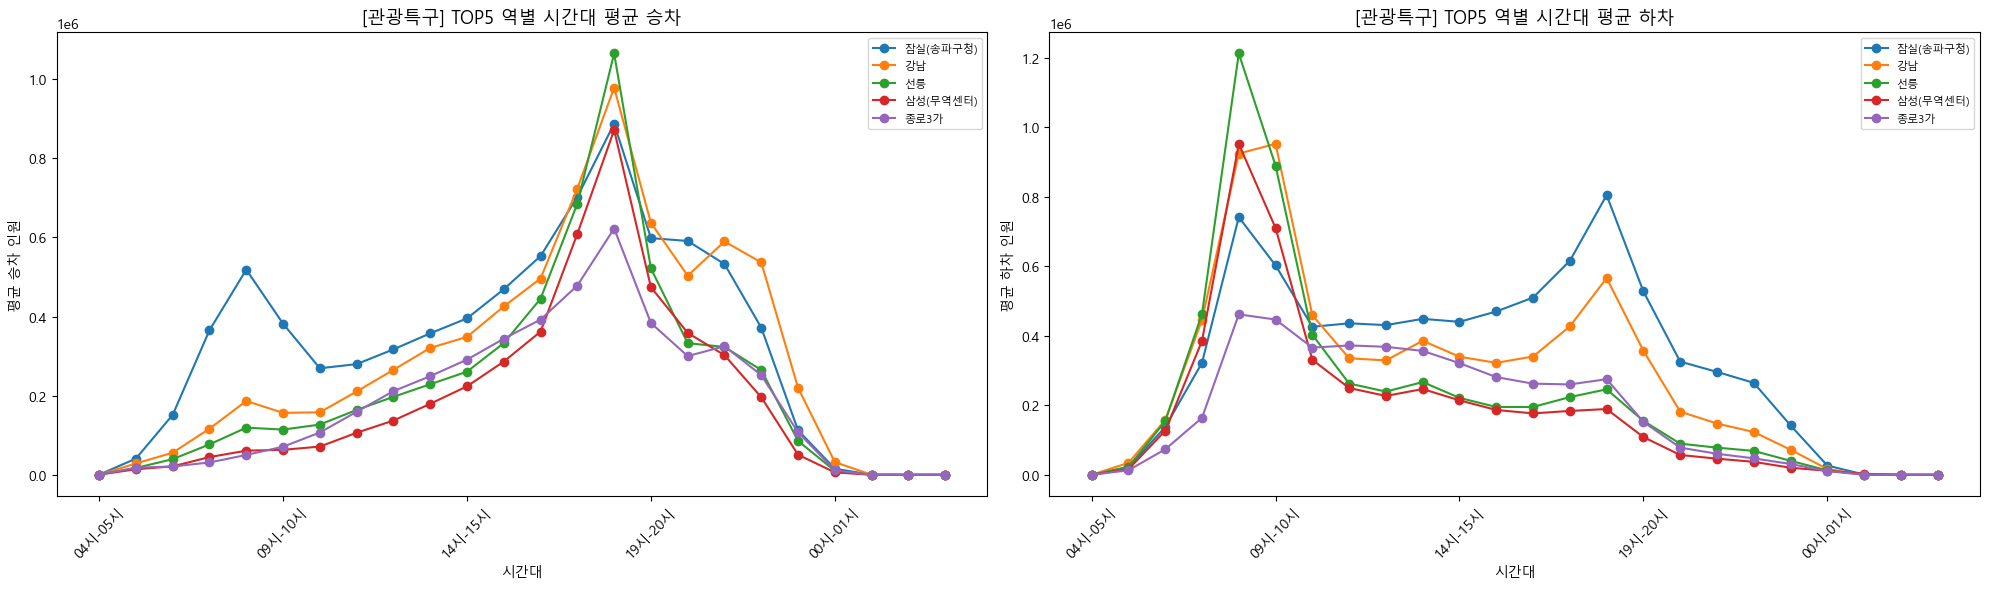


[관광특구] 역별 평균 피크 시간대
            승차_피크    하차_피크   평균_총승차   평균_총하차
지하철역                                        
잠실(송파구청)  18시-19시  18시-19시  7910521  7991637
강남        18시-19시  09시-10시  6988904  6917713
선릉        18시-19시  08시-09시  5411085  5440171
삼성(무역센터)  18시-19시  08시-09시  4439074  4478981
종로3가      18시-19시  08시-09시  4426136  4402263



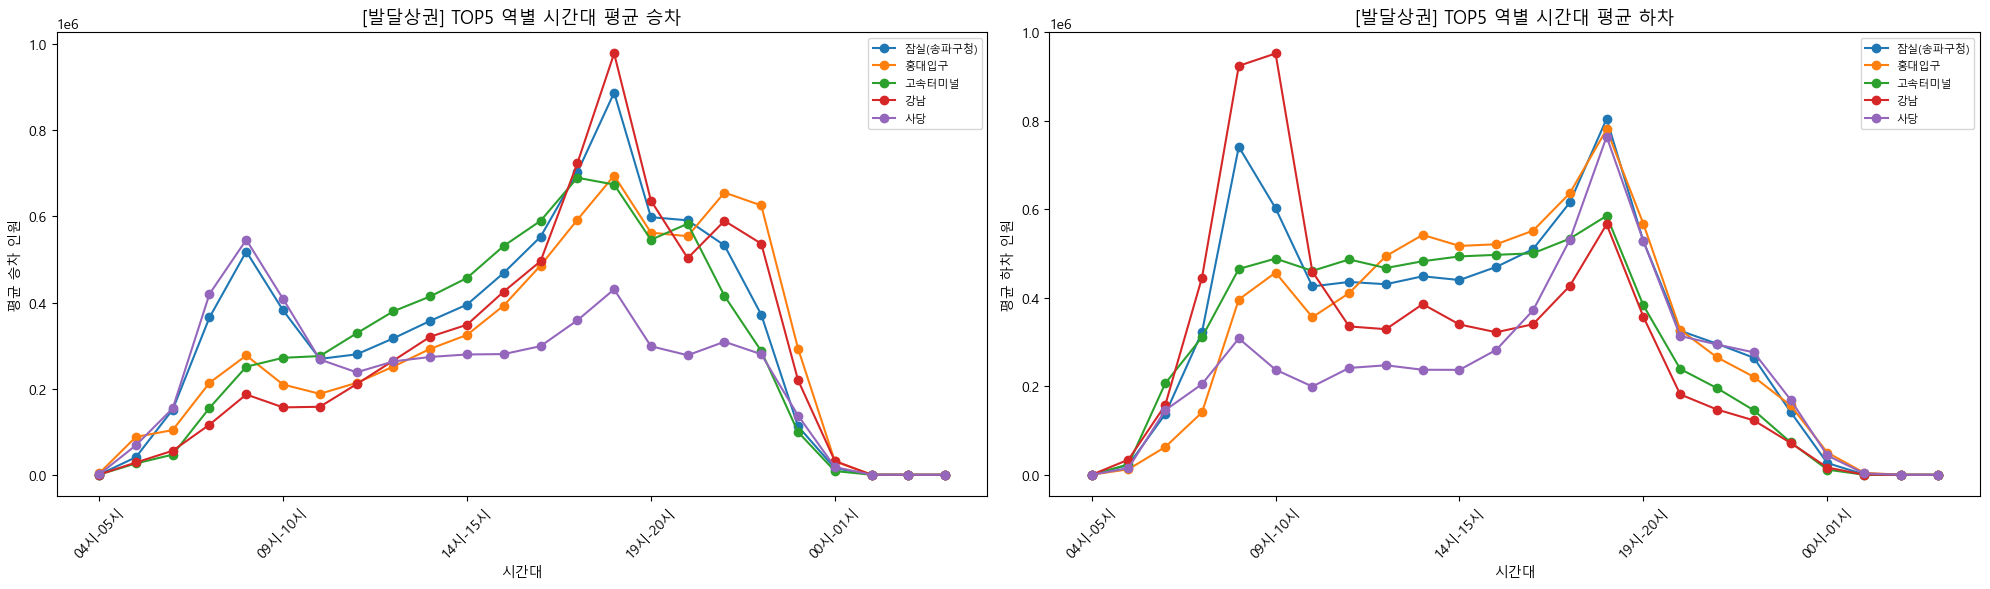


[발달상권] 역별 평균 피크 시간대
            승차_피크    하차_피크   평균_총승차   평균_총하차
지하철역                                        
잠실(송파구청)  18시-19시  18시-19시  7910521  7991637
홍대입구      18시-19시  18시-19시  7054115  7474877
고속터미널     17시-18시  18시-19시  7031882  7053297
강남        18시-19시  09시-10시  6988904  6917713
사당        08시-09시  18시-19시  5609300  5655675



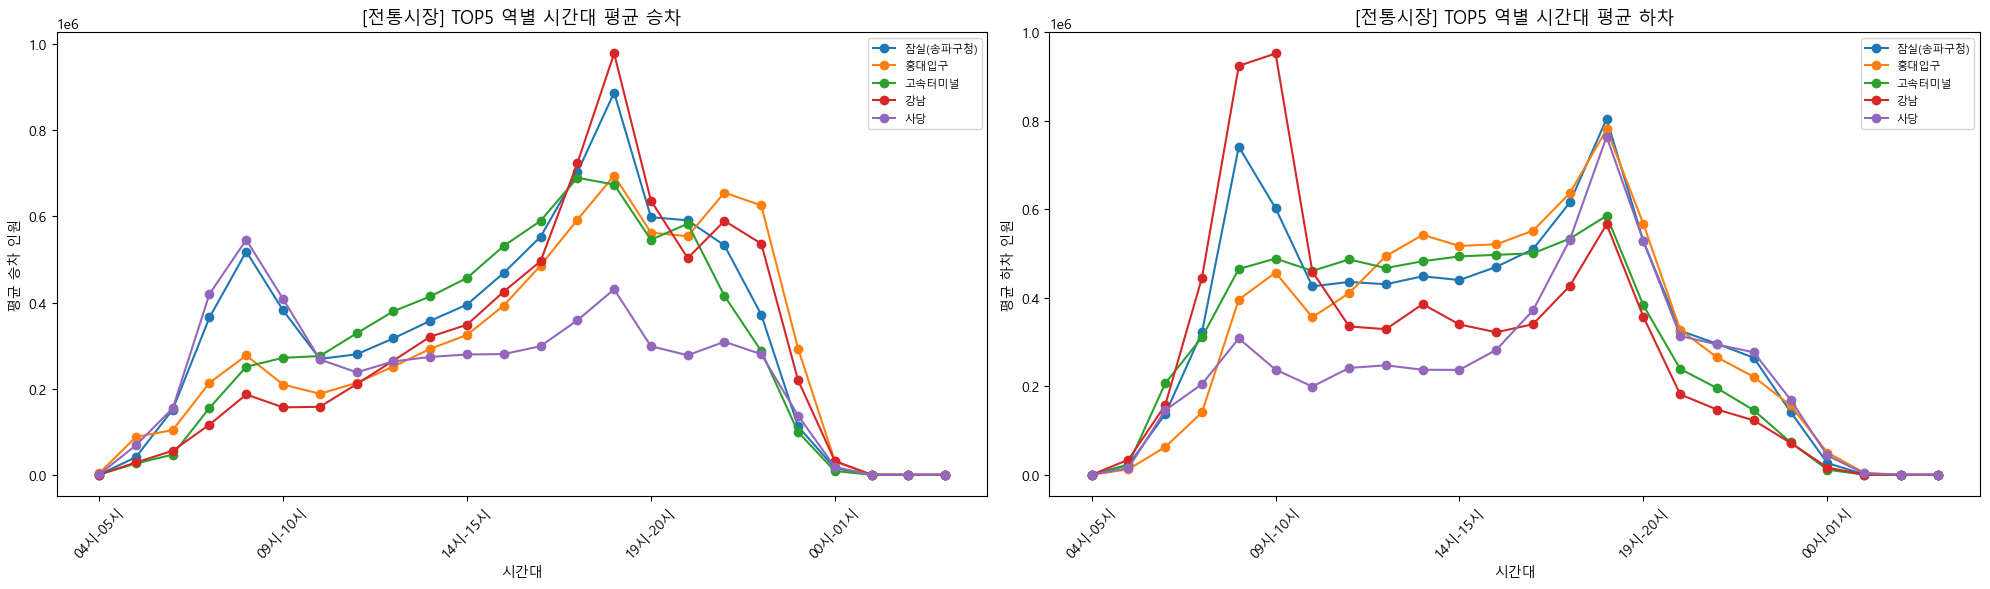


[전통시장] 역별 평균 피크 시간대
            승차_피크    하차_피크   평균_총승차   평균_총하차
지하철역                                        
잠실(송파구청)  18시-19시  18시-19시  7910521  7991637
홍대입구      18시-19시  18시-19시  7054115  7474877
고속터미널     17시-18시  18시-19시  7031882  7053297
강남        18시-19시  09시-10시  6988904  6917713
사당        08시-09시  18시-19시  5609300  5655675



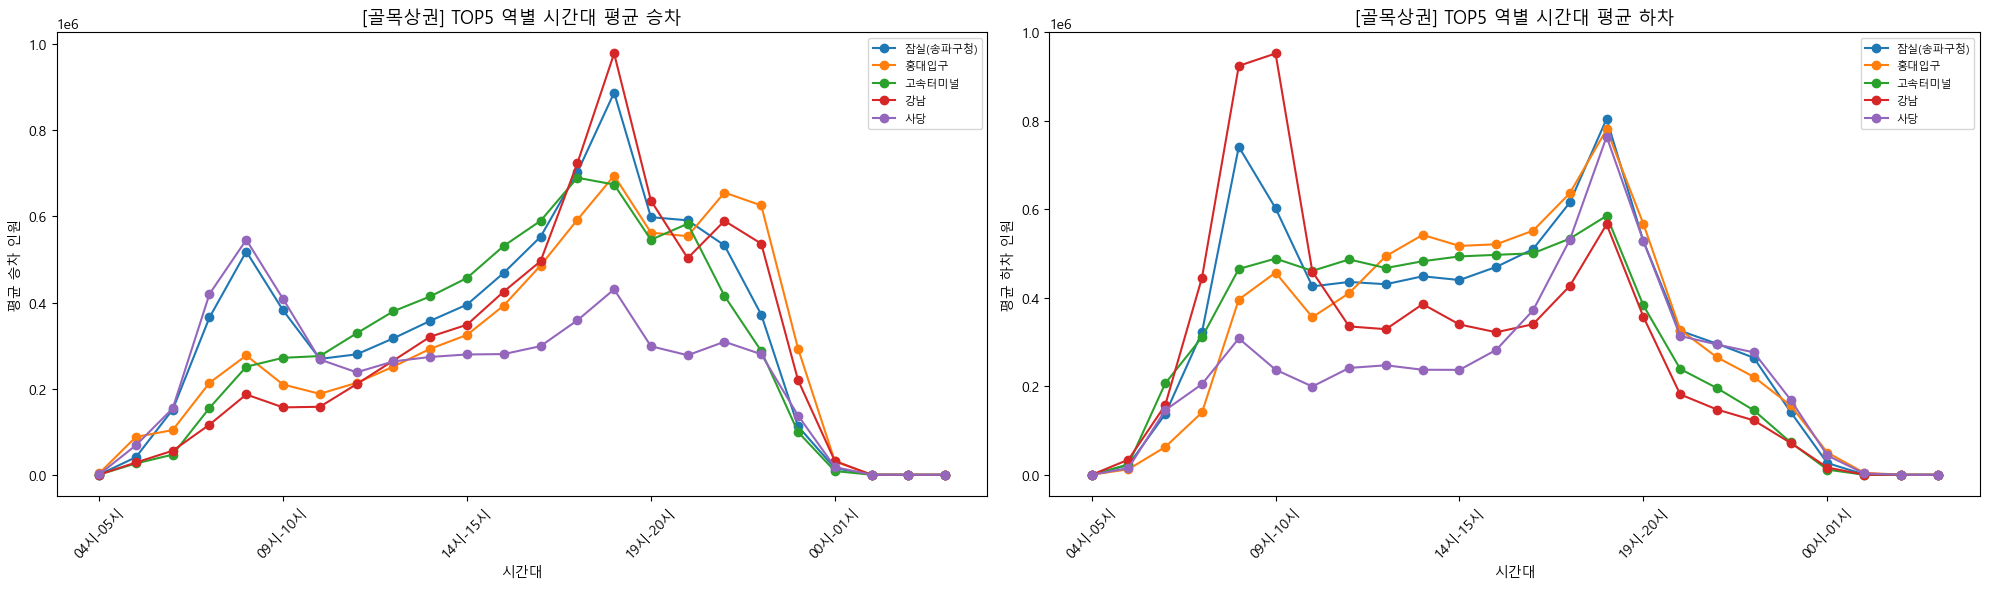


[골목상권] 역별 평균 피크 시간대
            승차_피크    하차_피크   평균_총승차   평균_총하차
지하철역                                        
잠실(송파구청)  18시-19시  18시-19시  7910521  7991637
홍대입구      18시-19시  18시-19시  7054115  7474877
고속터미널     17시-18시  18시-19시  7031882  7053297
강남        18시-19시  09시-10시  6988904  6917713
사당        08시-09시  18시-19시  5609300  5655675



In [18]:
# 상권 유형별 평균 승하차 분석
for 상권 in ['관광특구', '발달상권', '전통시장', '골목상권']:
    df_temp = df_final[df_final['상권_구분_코드_명'] == 상권]
    
    # 역별 시간대 평균 승차/하차
    평균_승차 = df_temp.groupby('지하철역')[승차_컬럼].mean()
    평균_하차 = df_temp.groupby('지하철역')[하차_컬럼].mean()
    
    # 총 평균 기준 TOP 5 역 추출
    top_역 = 평균_승차.sum(axis=1).nlargest(5).index
    
    평균_승차 = 평균_승차.loc[top_역]
    평균_하차 = 평균_하차.loc[top_역]
    
    # 컬럼명 정리
    평균_승차.columns = [c.replace(' 승차인원', '') for c in 평균_승차.columns]
    평균_하차.columns = [c.replace(' 하차인원', '') for c in 평균_하차.columns]

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    
    평균_승차.T.plot(ax=axes[0], marker='o')
    axes[0].set_title(f'[{상권}] TOP5 역별 시간대 평균 승차', fontsize=13)
    axes[0].set_xlabel('시간대')
    axes[0].set_ylabel('평균 승차 인원')
    axes[0].legend(fontsize=8)
    axes[0].tick_params(axis='x', rotation=45)

    평균_하차.T.plot(ax=axes[1], marker='o')
    axes[1].set_title(f'[{상권}] TOP5 역별 시간대 평균 하차', fontsize=13)
    axes[1].set_xlabel('시간대')
    axes[1].set_ylabel('평균 하차 인원')
    axes[1].legend(fontsize=8)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
    
    # 역별 피크 시간대 요약 출력
    print(f'\n[{상권}] 역별 평균 피크 시간대')
    피크 = pd.DataFrame({
        '승차_피크': 평균_승차.idxmax(axis=1),
        '하차_피크': 평균_하차.idxmax(axis=1),
        '평균_총승차': 평균_승차.sum(axis=1).astype(int),
        '평균_총하차': 평균_하차.sum(axis=1).astype(int)
    })
    print(피크.sort_values('평균_총승차', ascending=False))
    print()

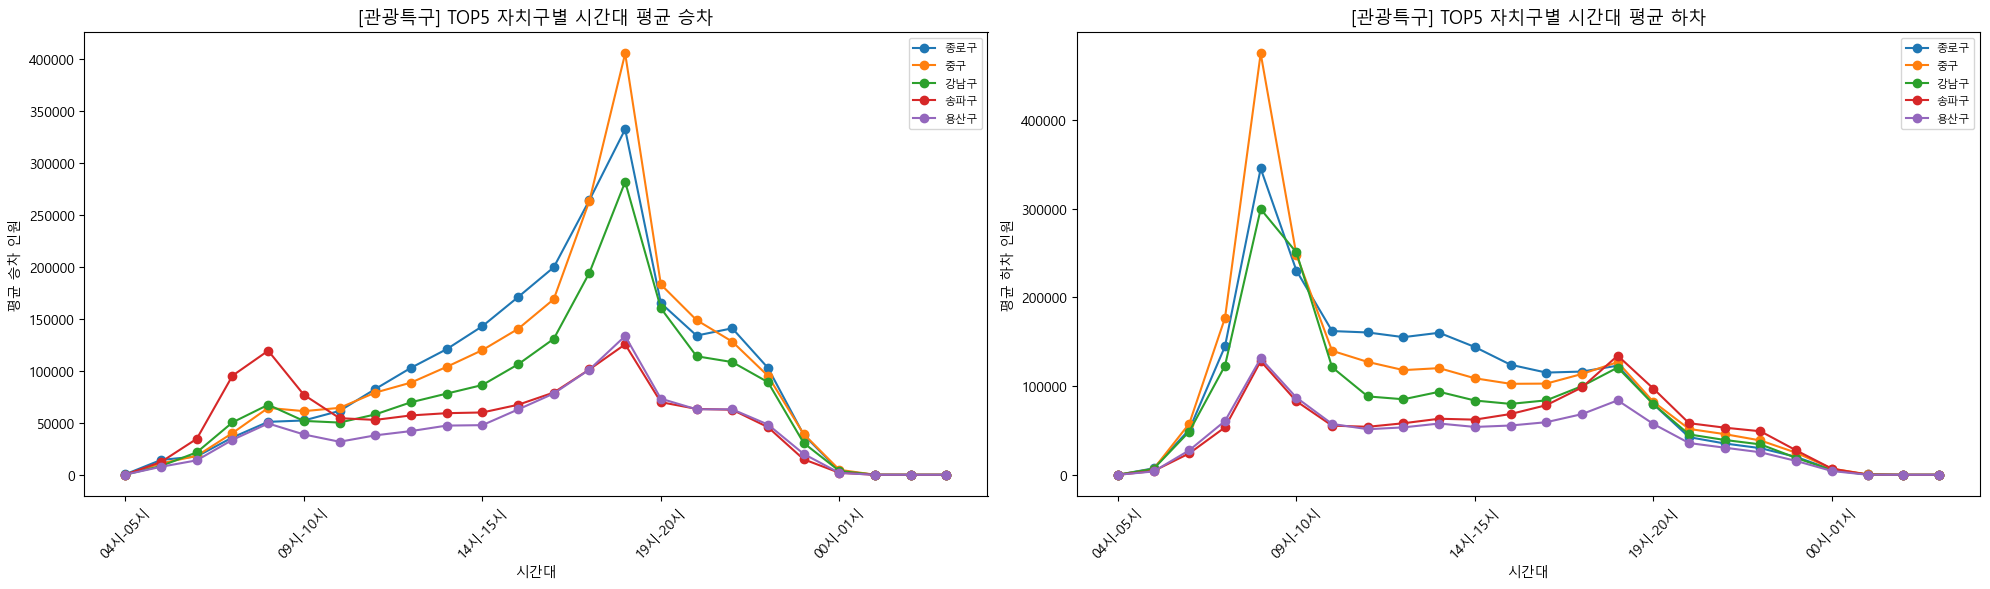


[관광특구] 자치구별 평균 피크 시간대
       승차_피크    하차_피크   평균_총승차   평균_총하차
자치구                                    
종로구  18시-19시  08시-09시  2237266  2254063
중구   18시-19시  08시-09시  2231144  2276136
강남구  18시-19시  08시-09시  1763943  1809555
송파구  18시-19시  18시-19시  1255741  1258612
용산구  18시-19시  08시-09시   997036  1020956



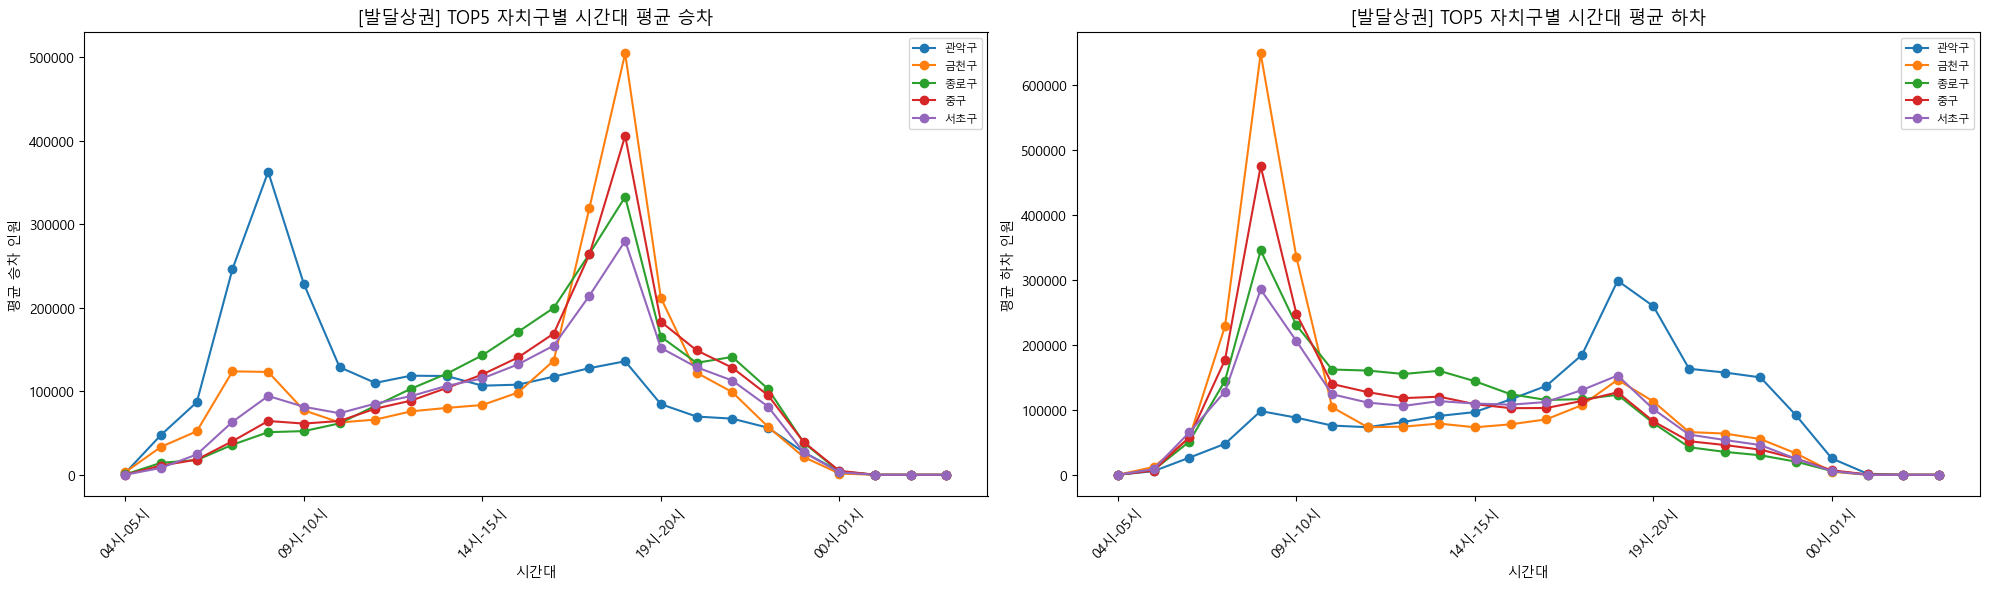


[발달상권] 자치구별 평균 피크 시간대
       승차_피크    하차_피크   평균_총승차   평균_총하차
자치구                                    
관악구  08시-09시  18시-19시  2355333  2268721
금천구  18시-19시  08시-09시  2354276  2436615
종로구  18시-19시  08시-09시  2237266  2254063
중구   18시-19시  08시-09시  2231144  2276136
서초구  18시-19시  08시-09시  2033805  2054153



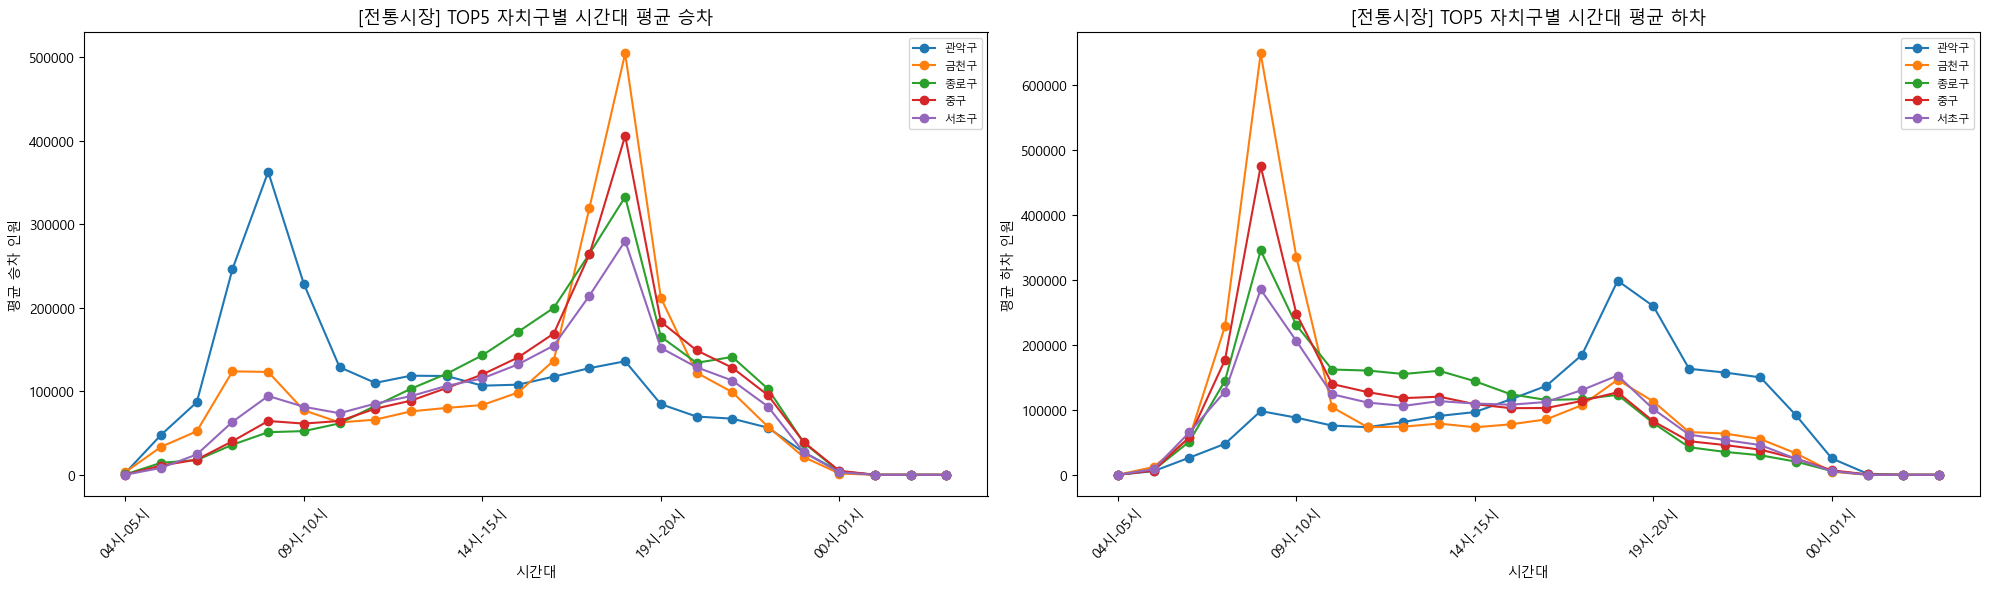


[전통시장] 자치구별 평균 피크 시간대
       승차_피크    하차_피크   평균_총승차   평균_총하차
자치구                                    
관악구  08시-09시  18시-19시  2355333  2268721
금천구  18시-19시  08시-09시  2354276  2436615
종로구  18시-19시  08시-09시  2237266  2254063
중구   18시-19시  08시-09시  2231144  2276136
서초구  18시-19시  08시-09시  2033805  2054153



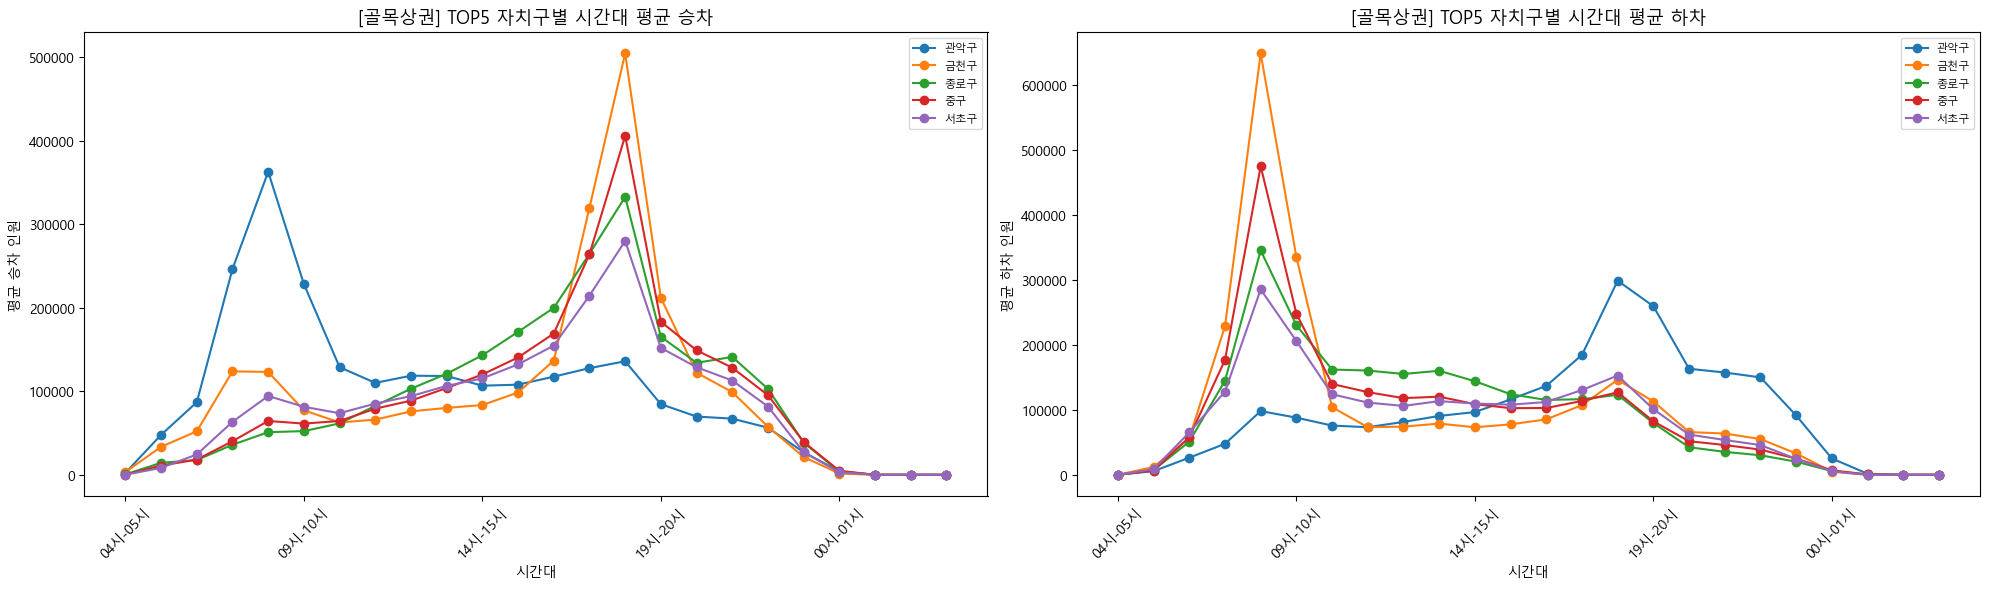


[골목상권] 자치구별 평균 피크 시간대
       승차_피크    하차_피크   평균_총승차   평균_총하차
자치구                                    
관악구  08시-09시  18시-19시  2355333  2268721
금천구  18시-19시  08시-09시  2354276  2436615
종로구  18시-19시  08시-09시  2237266  2254063
중구   18시-19시  08시-09시  2231144  2276136
서초구  18시-19시  08시-09시  2033805  2054153



In [19]:
for 상권 in ['관광특구', '발달상권', '전통시장', '골목상권']:
    df_temp = df_final[df_final['상권_구분_코드_명'] == 상권]
    
    # 자치구별 시간대 평균 승차/하차
    평균_승차 = df_temp.groupby('자치구')[승차_컬럼].mean()
    평균_하차 = df_temp.groupby('자치구')[하차_컬럼].mean()
    
    # 총 평균 기준 TOP 5 자치구 추출
    top_구 = 평균_승차.sum(axis=1).nlargest(5).index
    
    평균_승차 = 평균_승차.loc[top_구]
    평균_하차 = 평균_하차.loc[top_구]
    
    # 컬럼명 정리
    평균_승차.columns = [c.replace(' 승차인원', '') for c in 평균_승차.columns]
    평균_하차.columns = [c.replace(' 하차인원', '') for c in 평균_하차.columns]

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    
    평균_승차.T.plot(ax=axes[0], marker='o')
    axes[0].set_title(f'[{상권}] TOP5 자치구별 시간대 평균 승차', fontsize=13)
    axes[0].set_xlabel('시간대')
    axes[0].set_ylabel('평균 승차 인원')
    axes[0].legend(fontsize=8)
    axes[0].tick_params(axis='x', rotation=45)

    평균_하차.T.plot(ax=axes[1], marker='o')
    axes[1].set_title(f'[{상권}] TOP5 자치구별 시간대 평균 하차', fontsize=13)
    axes[1].set_xlabel('시간대')
    axes[1].set_ylabel('평균 하차 인원')
    axes[1].legend(fontsize=8)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
    
    # 자치구별 피크 시간대 요약
    print(f'\n[{상권}] 자치구별 평균 피크 시간대')
    피크 = pd.DataFrame({
        '승차_피크': 평균_승차.idxmax(axis=1),
        '하차_피크': 평균_하차.idxmax(axis=1),
        '평균_총승차': 평균_승차.sum(axis=1).astype(int),
        '평균_총하차': 평균_하차.sum(axis=1).astype(int)
    })
    print(피크.sort_values('평균_총승차', ascending=False))
    print()

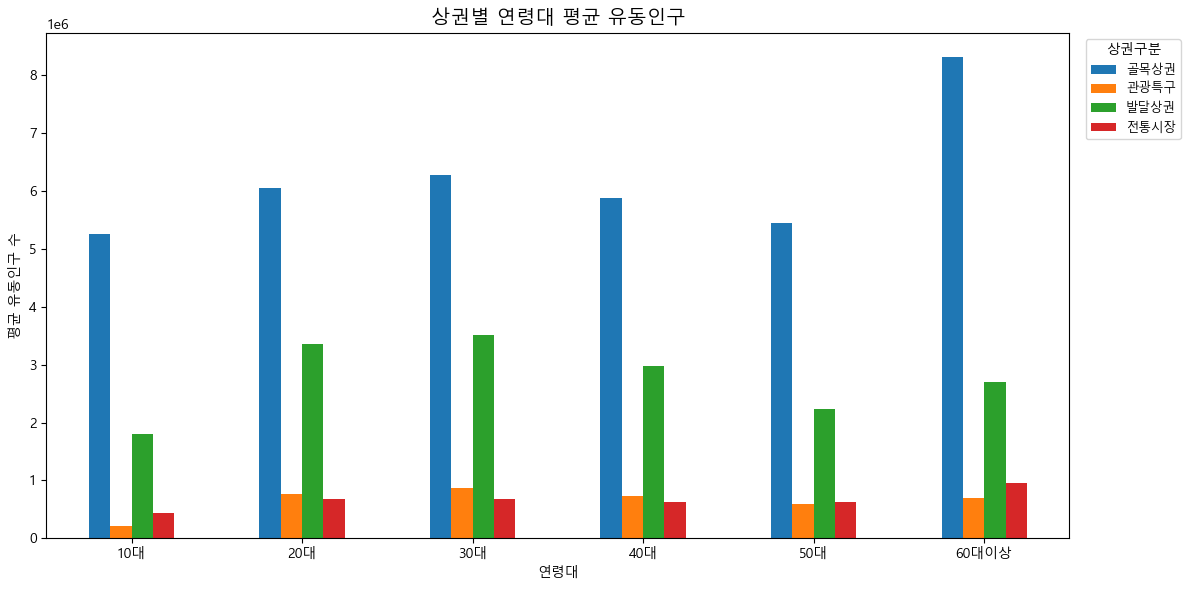

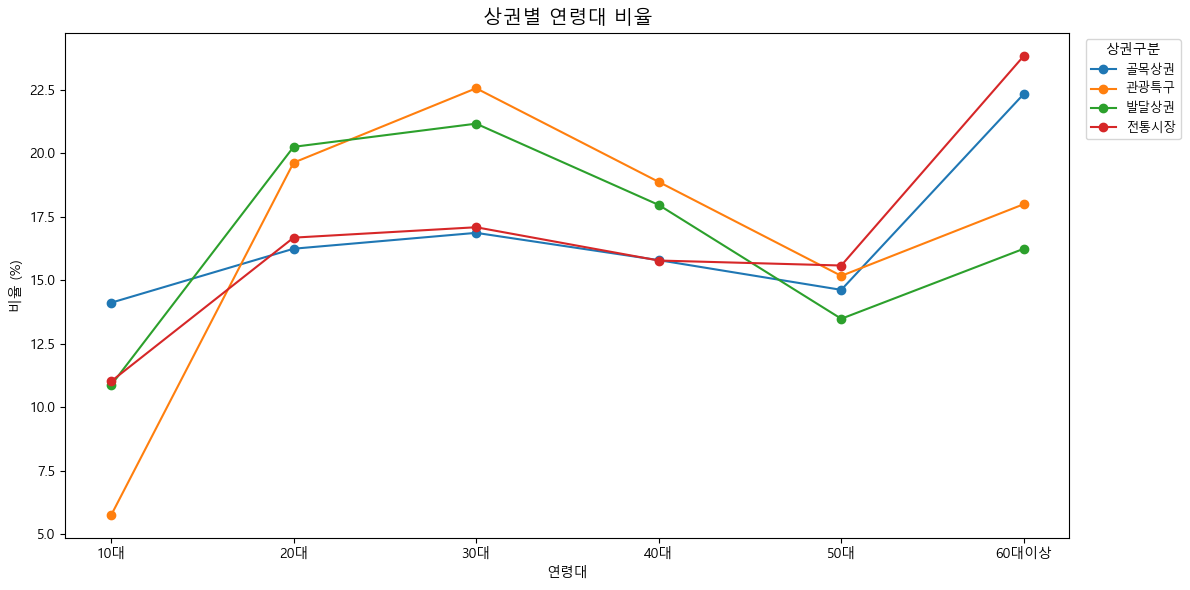

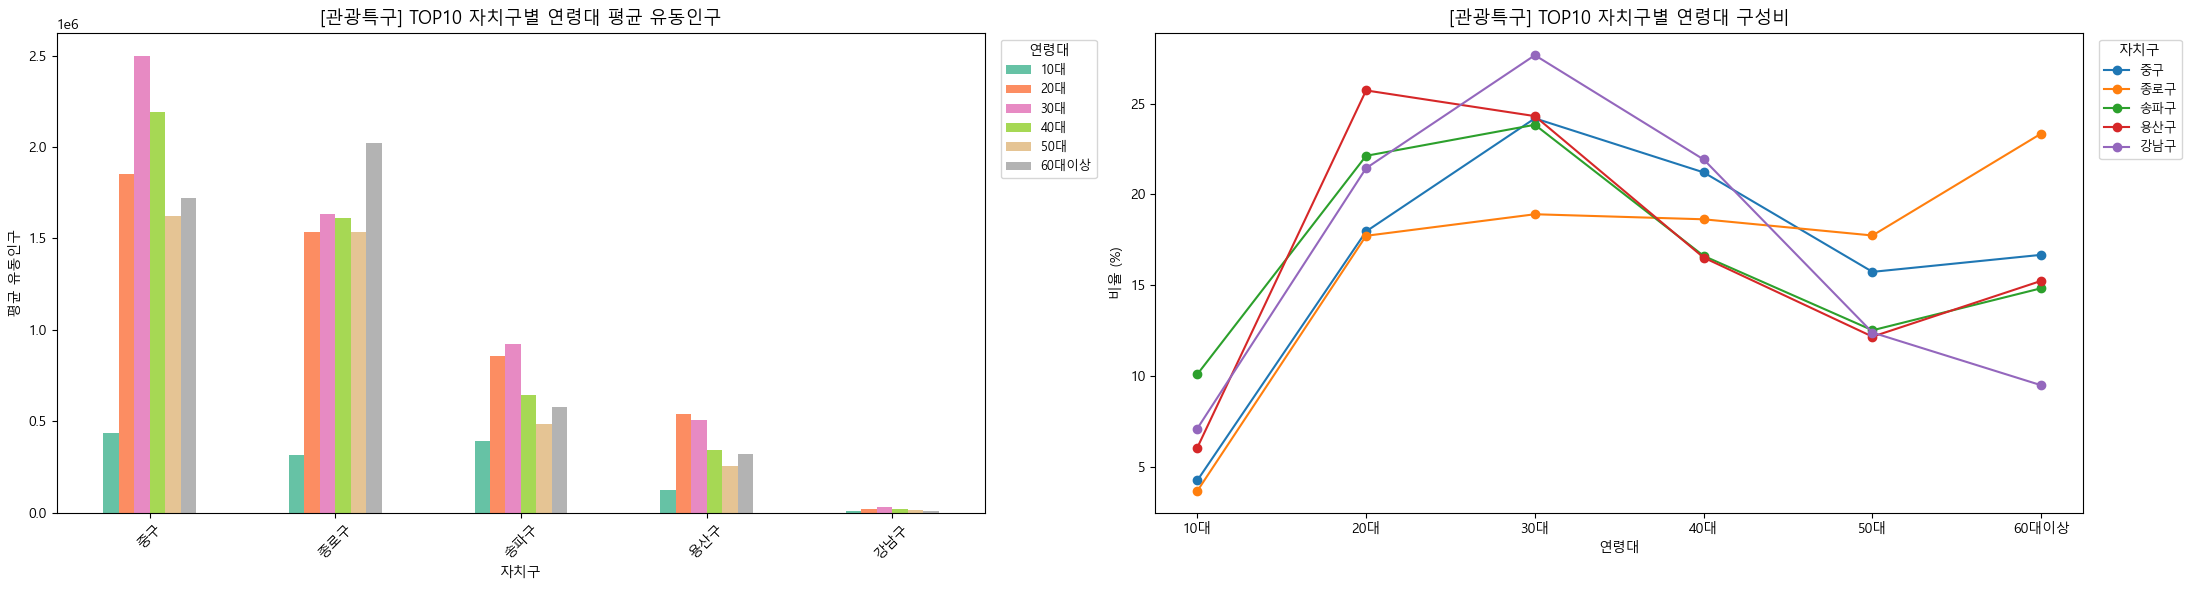


[관광특구] 자치구별 주요 연령대
     주요연령대    총_유동인구
자치구                 
중구     30대  10323903
종로구  60대이상   8656676
송파구    30대   3882330
용산구    20대   2093369
강남구    30대    106557



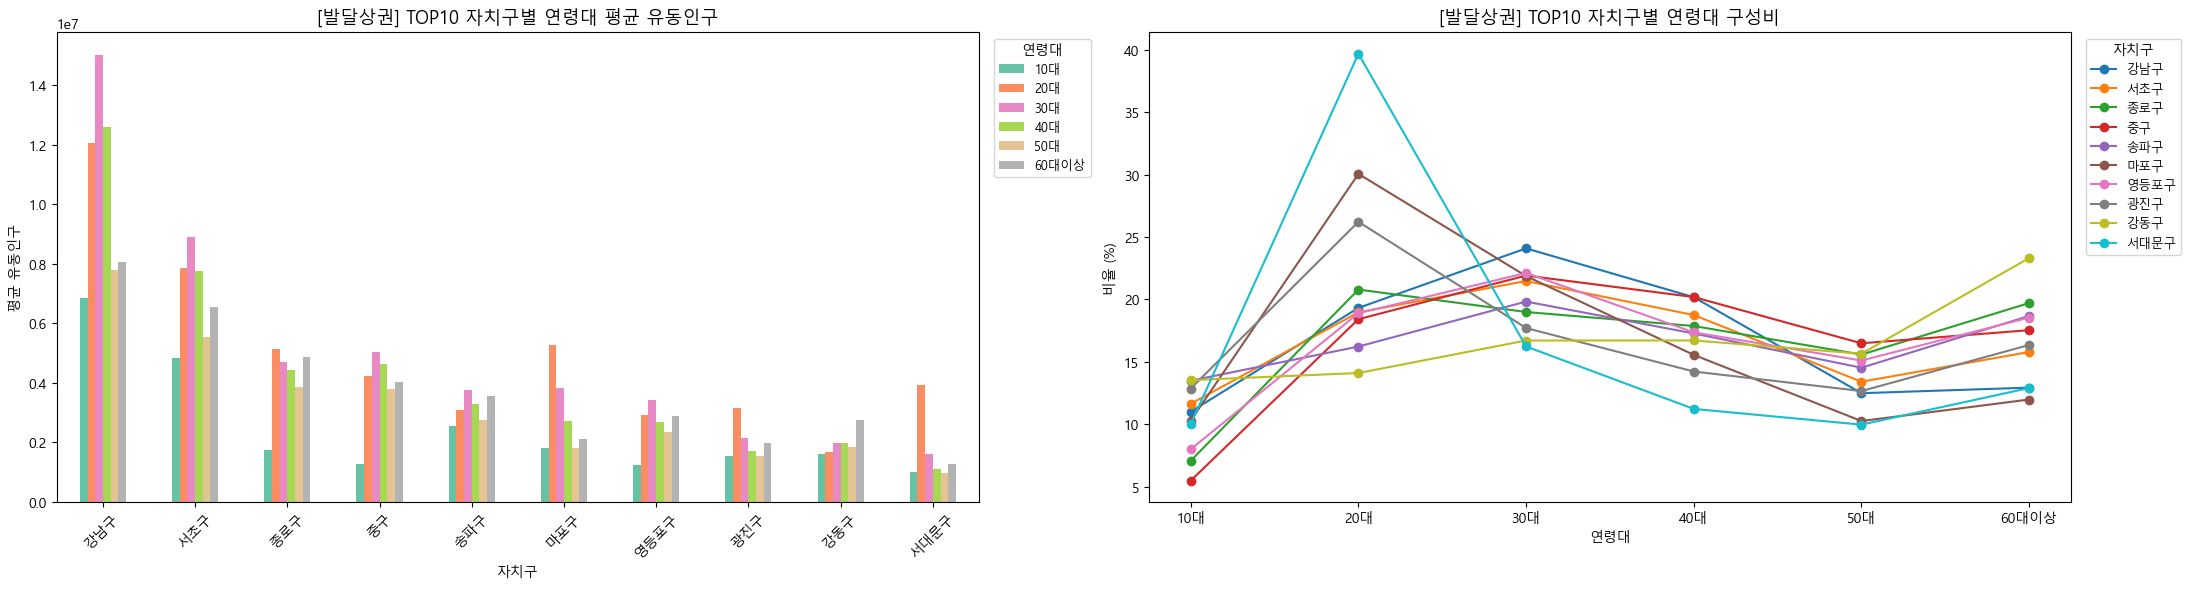


[발달상권] 자치구별 주요 연령대
      주요연령대    총_유동인구
자치구                  
강남구     30대  62336555
서초구     30대  41405178
종로구     20대  24756105
중구      30대  22977461
송파구     30대  19031457
마포구     20대  17528471
영등포구    30대  15492213
광진구     20대  12063658
강동구   60대이상  11831115
서대문구    20대   9919177



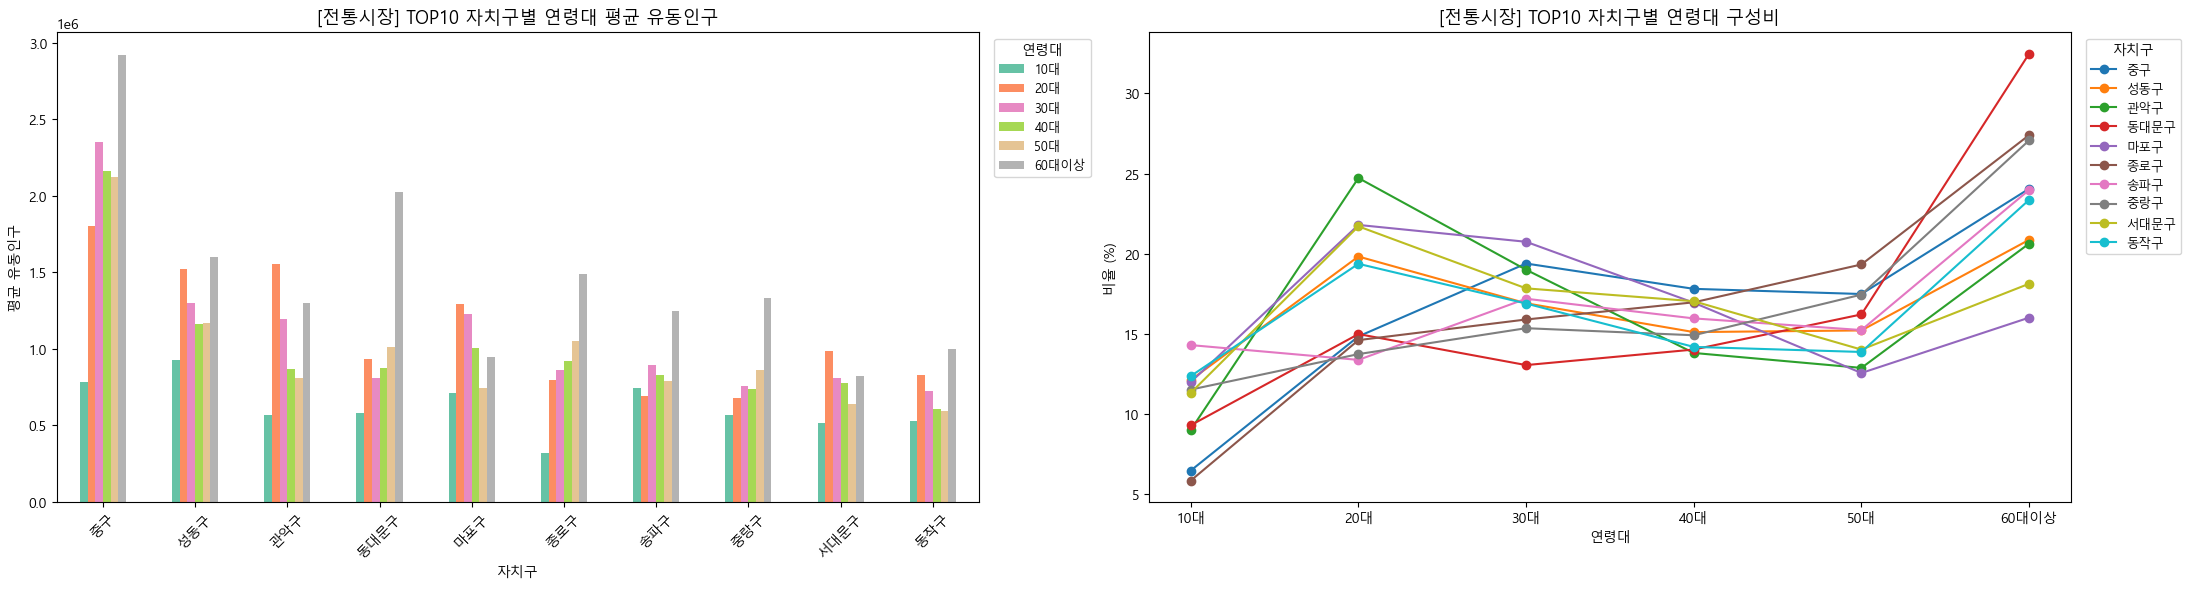


[전통시장] 자치구별 주요 연령대
      주요연령대    총_유동인구
자치구                  
중구    60대이상  12148917
성동구   60대이상   7682914
관악구     20대   6296290
동대문구  60대이상   6229786
마포구     20대   5933516
종로구   60대이상   5439160
송파구   60대이상   5190898
중랑구   60대이상   4931713
서대문구    20대   4557123
동작구   60대이상   4291980



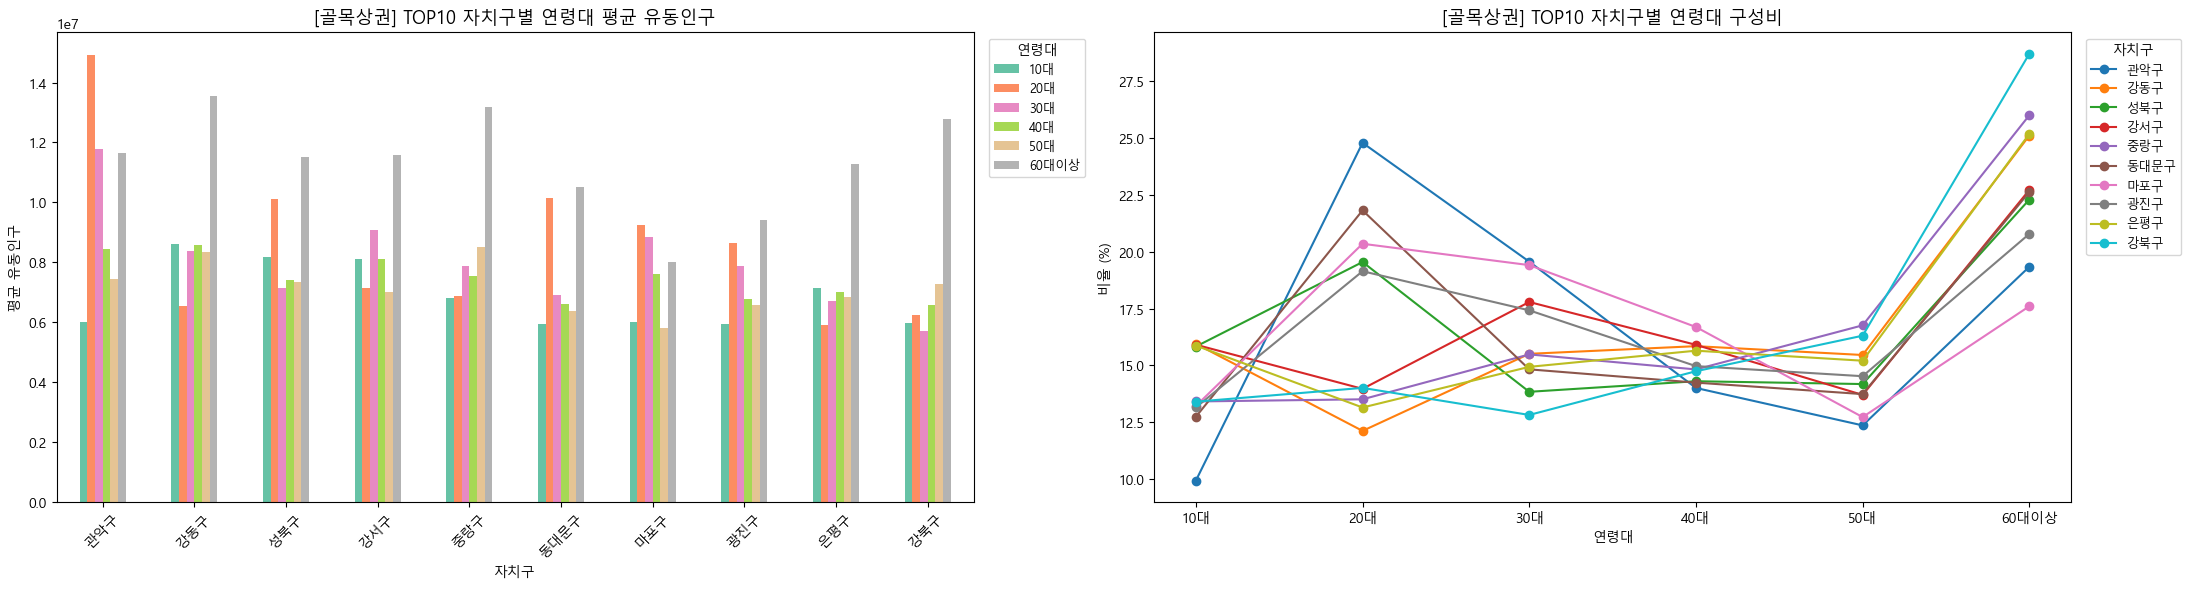


[골목상권] 자치구별 주요 연령대
      주요연령대    총_유동인구
자치구                  
관악구     20대  60249274
강동구   60대이상  54017731
성북구   60대이상  51706193
강서구   60대이상  51022996
중랑구   60대이상  50786326
동대문구  60대이상  46474912
마포구     20대  45513971
광진구   60대이상  45248697
은평구   60대이상  44888726
강북구   60대이상  44560196



In [20]:
연령대_컬럼 = [c for c in df_final.columns if '연령대' in c]

# ── 1. 상권별 연령대 평균 유동인구 ──────────────────────────

상권별_연령 = df_final.groupby('상권_구분_코드_명')[연령대_컬럼].mean()

상권별_연령.columns = ['10대', '20대', '30대', '40대', '50대', '60대이상']

fig, ax = plt.subplots(figsize=(12, 6))

상권별_연령.T.plot(kind='bar', ax=ax)

ax.set_title('상권별 연령대 평균 유동인구', fontsize=14)

ax.set_xlabel('연령대')

ax.set_ylabel('평균 유동인구 수')

ax.legend(title='상권구분', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

ax.tick_params(axis='x', rotation=0)

plt.tight_layout()

plt.show()

# ── 2. 상권별 연령대 비율 → 라인 그래프 ──────────────────────────

상권별_비율 = 상권별_연령.div(상권별_연령.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))

상권별_비율.T.plot(kind='line', ax=ax, marker='o')  # 행/열 전환해서 연령대가 x축

ax.set_title('상권별 연령대 비율', fontsize=14)

ax.set_xlabel('연령대')

ax.set_ylabel('비율 (%)')

ax.legend(title='상권구분', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

ax.tick_params(axis='x', rotation=0)

plt.tight_layout()

plt.show()

# ── 3. 자치구 × 상권별 연령대 TOP 분석 ──────────────────────

for 상권 in ['관광특구', '발달상권', '전통시장', '골목상권']:

    df_temp = df_final[df_final['상권_구분_코드_명'] == 상권]

    

    구별_연령 = df_temp.groupby('자치구')[연령대_컬럼].mean()

    구별_연령.columns = ['10대', '20대', '30대', '40대', '50대', '60대이상']

    

    top_구 = 구별_연령.sum(axis=1).nlargest(10).index

    구별_연령 = 구별_연령.loc[top_구]

    fig, axes = plt.subplots(1, 2, figsize=(22, 6))

    # 절대값 막대

    구별_연령.plot(kind='bar', ax=axes[0], colormap='Set2')

    axes[0].set_title(f'[{상권}] TOP10 자치구별 연령대 평균 유동인구', fontsize=13)

    axes[0].set_xlabel('자치구')

    axes[0].set_ylabel('평균 유동인구')

    axes[0].tick_params(axis='x', rotation=45)

    axes[0].legend(title='연령대', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

    # 비율 라인 그래프

    구별_비율 = 구별_연령.div(구별_연령.sum(axis=1), axis=0) * 100

    구별_비율.T.plot(kind='line', ax=axes[1], marker='o')  # 연령대가 x축, 자치구가 선

    axes[1].set_title(f'[{상권}] TOP10 자치구별 연령대 구성비', fontsize=13)

    axes[1].set_xlabel('연령대')

    axes[1].set_ylabel('비율 (%)')

    axes[1].tick_params(axis='x', rotation=0)

    axes[1].legend(title='자치구', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

    plt.tight_layout()

    plt.show()

    print(f'\n[{상권}] 자치구별 주요 연령대')

    요약 = pd.DataFrame({

        '주요연령대': 구별_연령.idxmax(axis=1),

        '총_유동인구': 구별_연령.sum(axis=1).astype(int)

    }).sort_values('총_유동인구', ascending=False)

    print(요약)

    print()

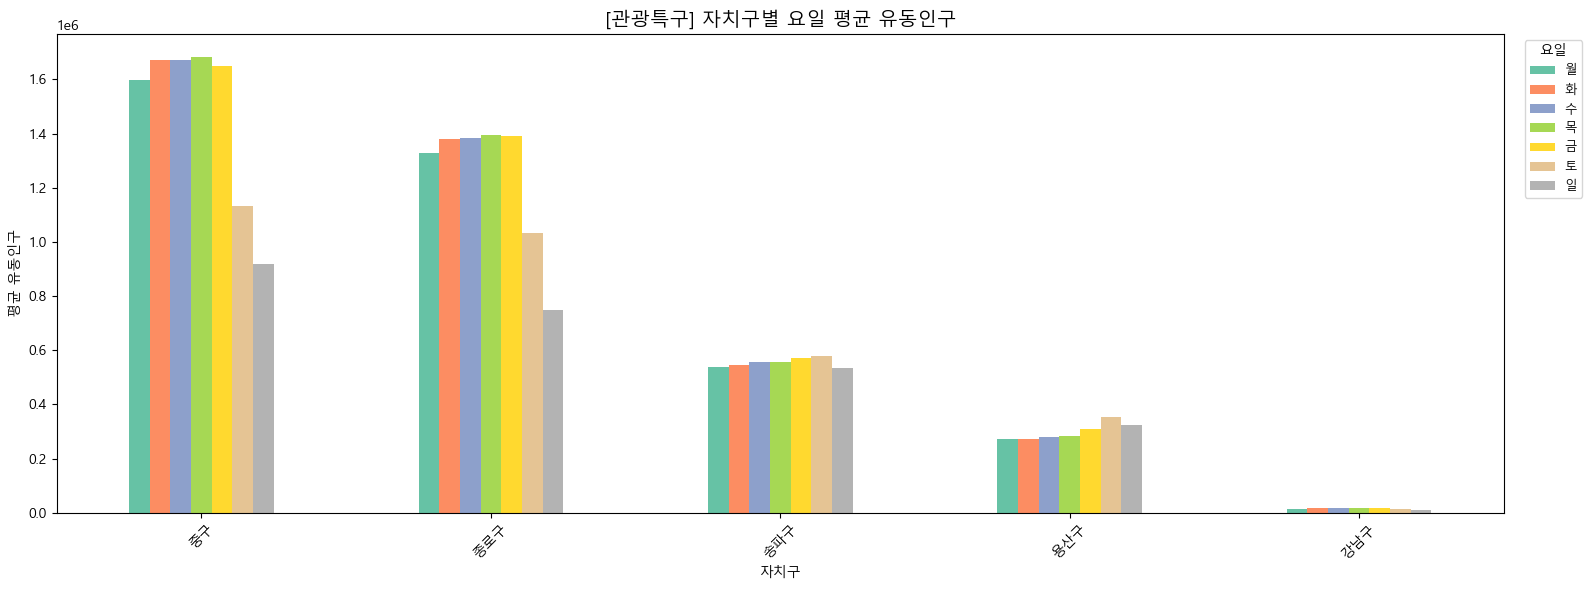

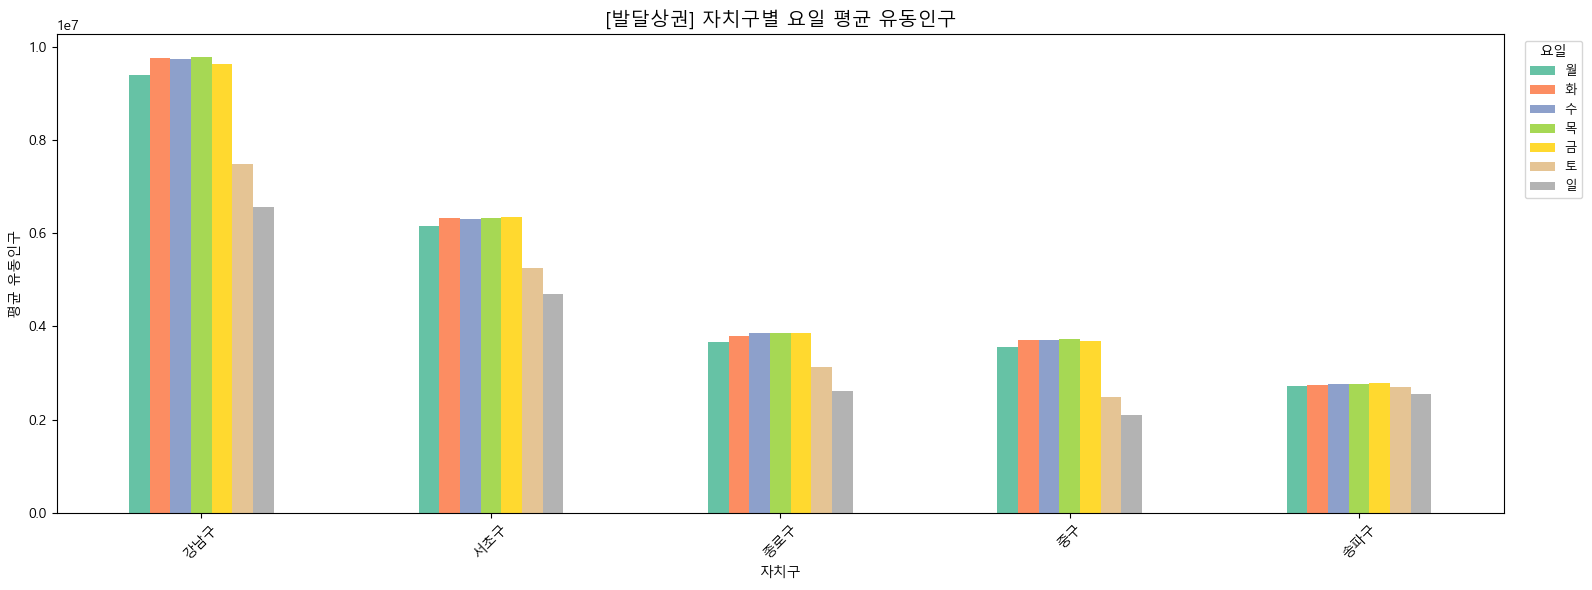

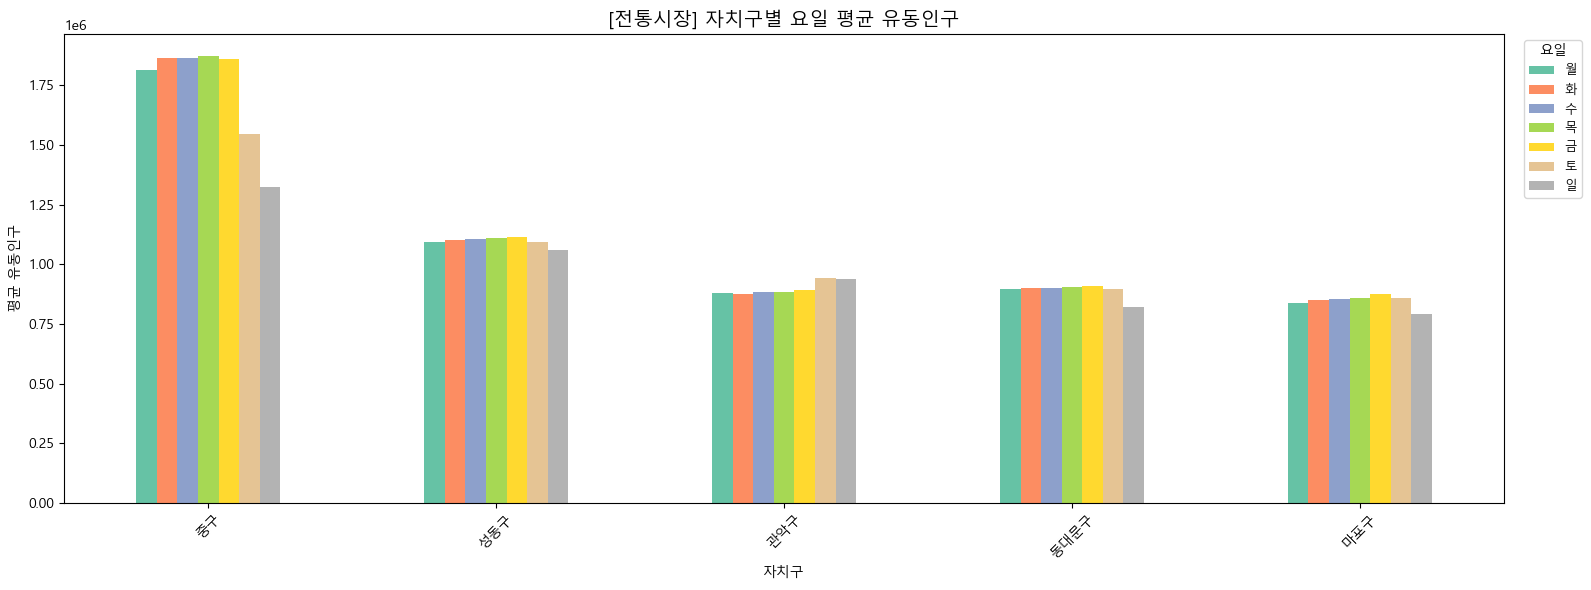

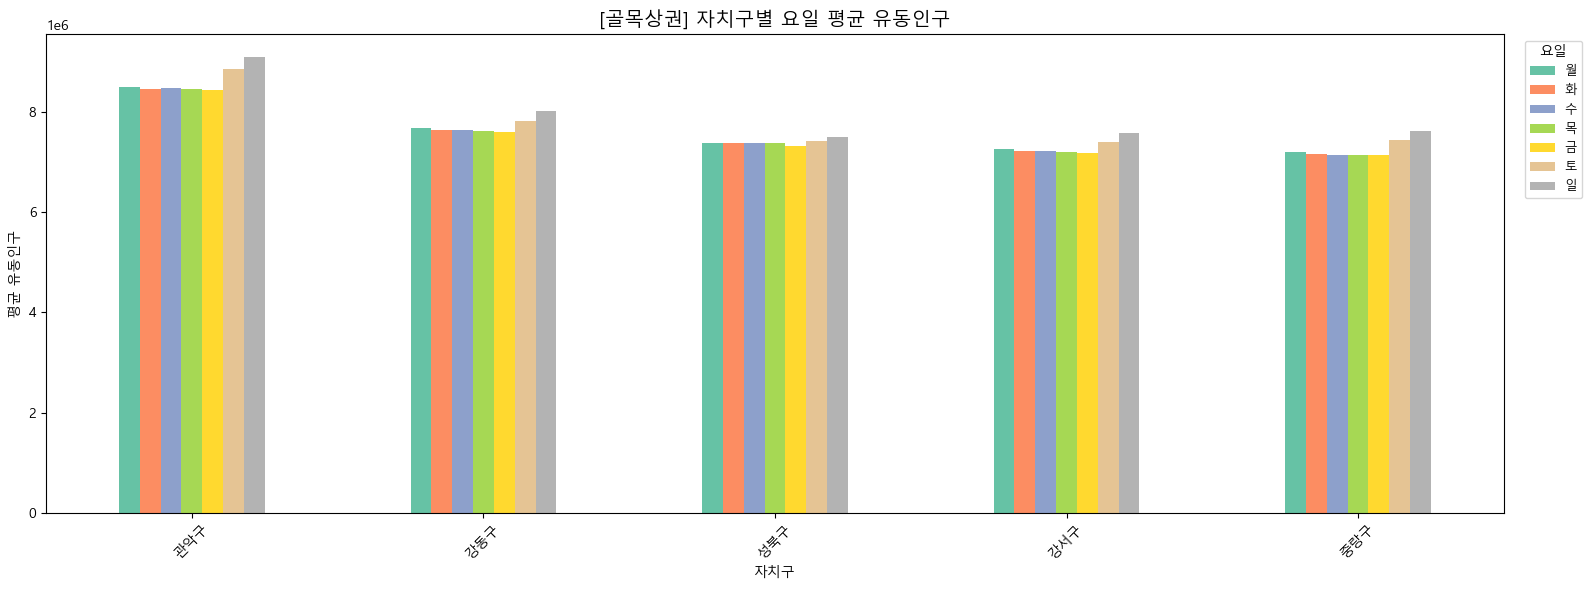

In [22]:
요일_컬럼 = [c for c in df_final.columns if '요일_유동인구_수' in c]

# 자치구 × 상권별 요일 평균 유동인구
요일_평균 = df_final.groupby(['자치구', '상권_구분_코드_명'])[요일_컬럼].mean()
요일_평균.columns = ['월', '화', '수', '목', '금', '토', '일']

for 상권 in ['관광특구', '발달상권', '전통시장', '골목상권']:
    df_plot = 요일_평균.xs(상권, level='상권_구분_코드_명')
    
    # TOP 5 자치구만
    top_구 = df_plot.sum(axis=1).nlargest(5).index
    df_plot = df_plot.loc[top_구]

    fig, ax = plt.subplots(figsize=(16, 6))
    df_plot.plot(kind='bar', ax=ax, colormap='Set2')
    ax.set_title(f'[{상권}] 자치구별 요일 평균 유동인구', fontsize=14)
    ax.set_xlabel('자치구')
    ax.set_ylabel('평균 유동인구')
    ax.legend(title='요일', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

In [23]:

df_com['연도'] = df_com['기준_년분기_코드'].astype(str).str[:4]

성별_분석 = df_com.groupby(
    ['연도', '상권_구분_코드_명', '자치구']
)[['남성_유동인구_수', '여성_유동인구_수']].mean().reset_index()

print(성별_분석.shape)
print(성별_분석.head())

(560, 5)
     연도 상권_구분_코드_명  자치구      남성_유동인구_수      여성_유동인구_수
0  2019       골목상권  강남구  257012.472222  279553.583333
1  2019       골목상권  강동구  643549.087209  728417.494186
2  2019       골목상권  강북구  465177.355556  560384.211111
3  2019       골목상권  강서구  481350.852941  554051.416667
4  2019       골목상권  관악구  620378.155000  641496.880000


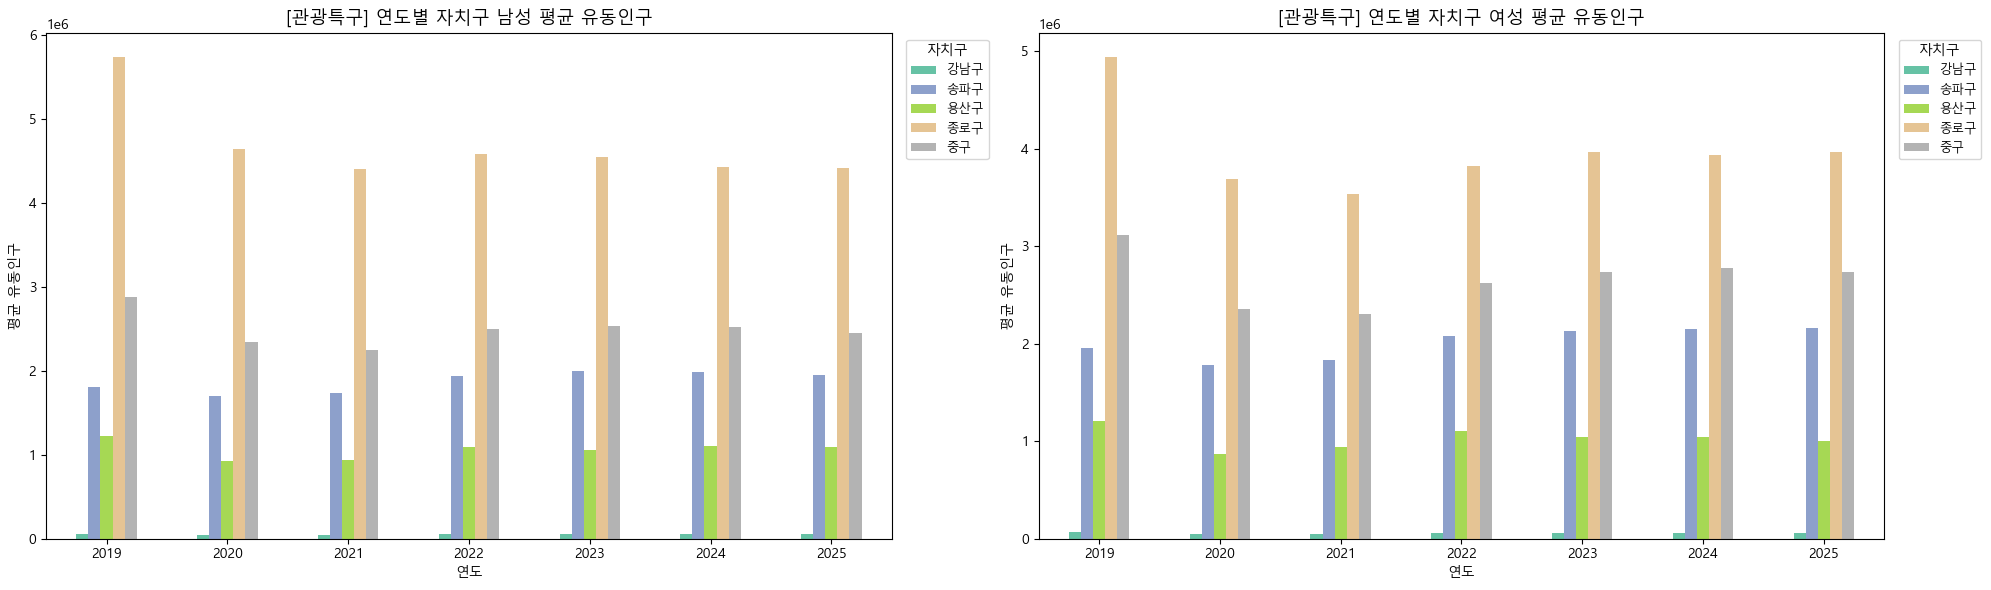


[관광특구] 연도별 남녀 평균 유동인구 TOP5 자치구
     남성_유동인구_수  여성_유동인구_수
자치구                      
종로구    4676422    3980255
중구     2496387    2665565
송파구    1869934    2012396
용산구    1062287    1031082
강남구      52510      54048



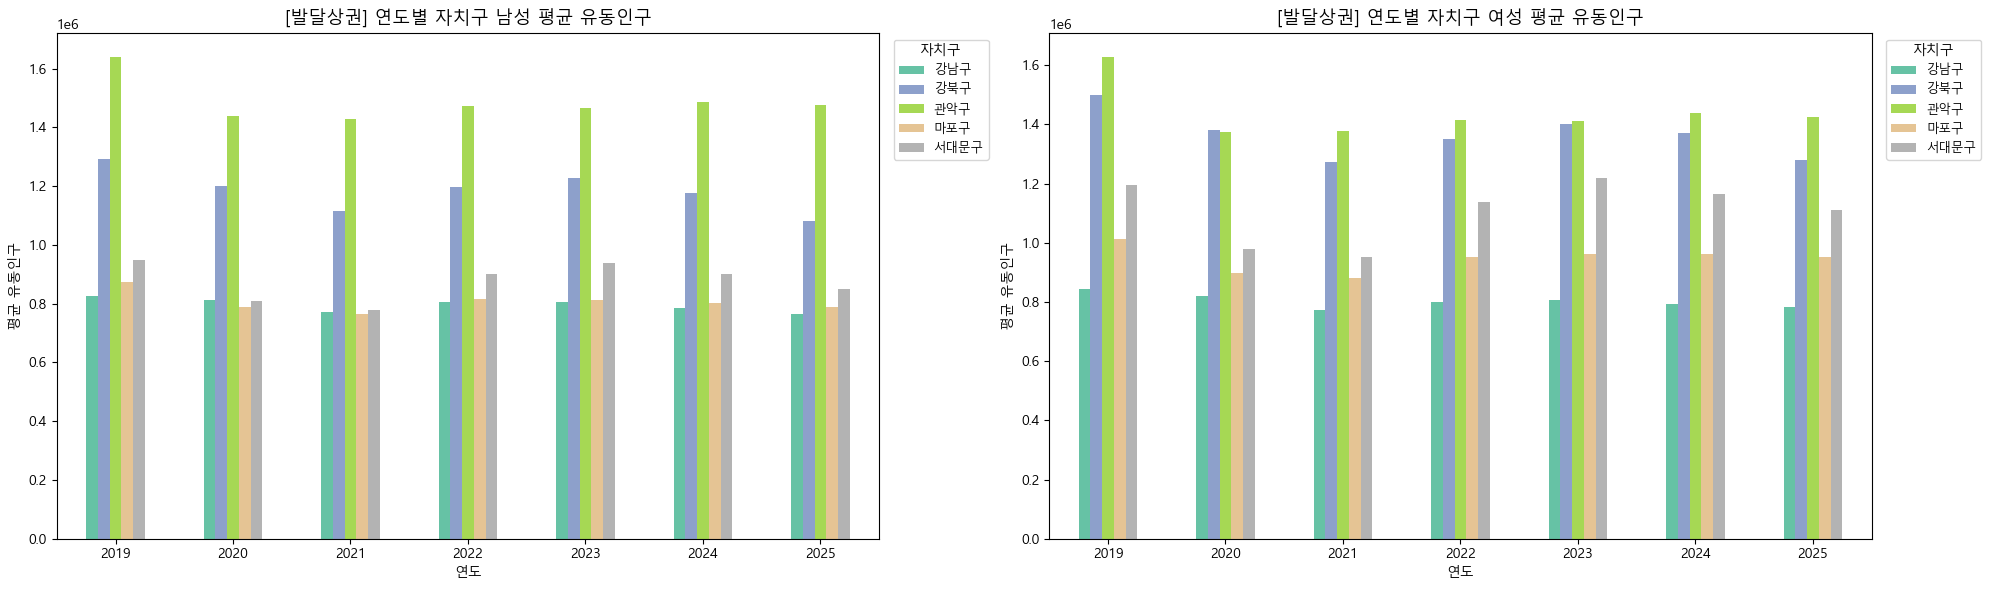


[발달상권] 연도별 남녀 평균 유동인구 TOP5 자치구
      남성_유동인구_수  여성_유동인구_수
자치구                       
관악구     1487320    1439173
강북구     1184691    1365226
서대문구     875479    1108357
마포구      807245     945602
강남구      795961     802412



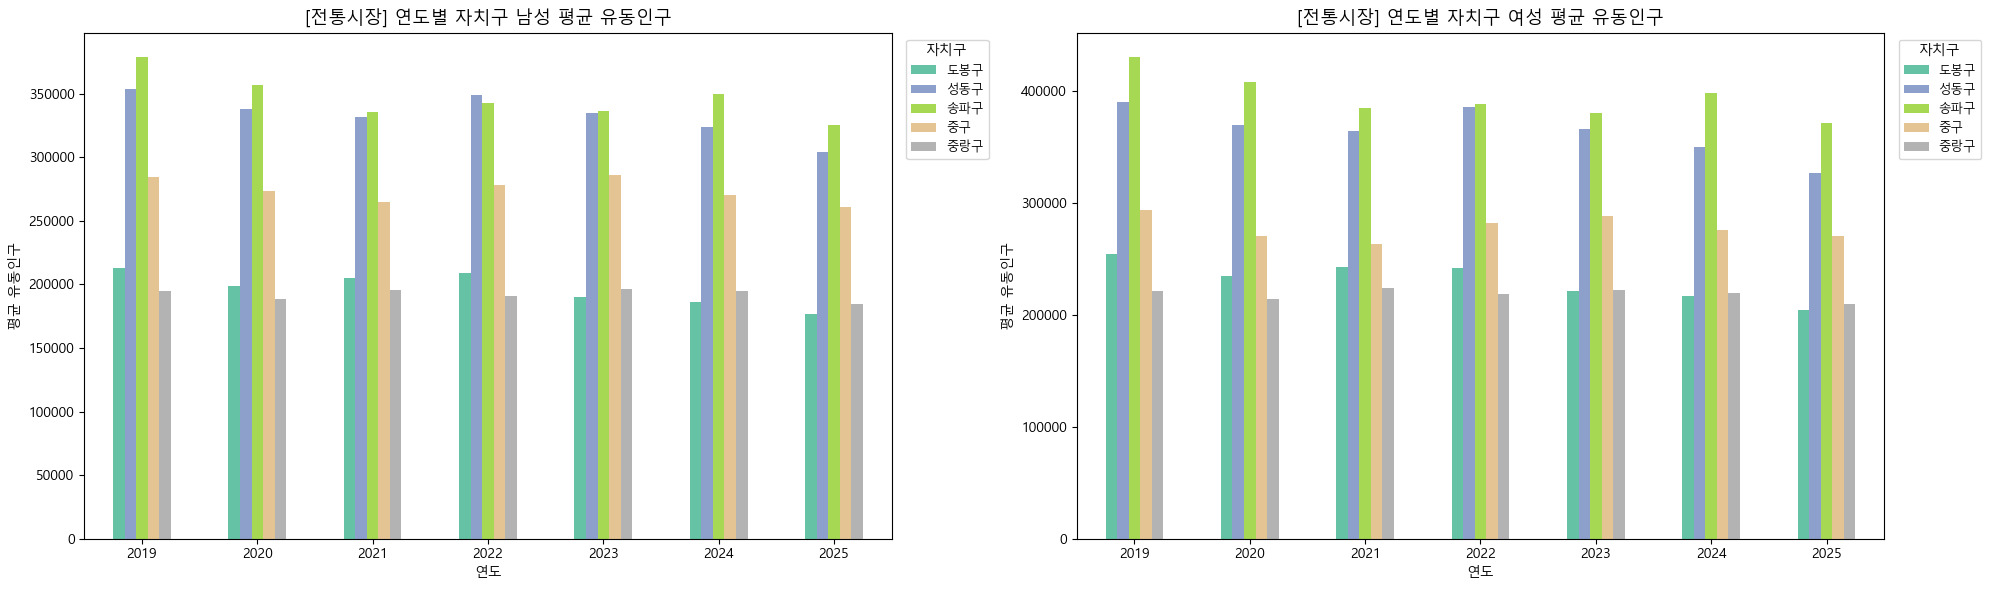


[전통시장] 연도별 남녀 평균 유동인구 TOP5 자치구
     남성_유동인구_수  여성_유동인구_수
자치구                      
송파구     346637     394920
성동구     333473     364974
중구      274055     278168
도봉구     197095     231385
중랑구     192323     218651



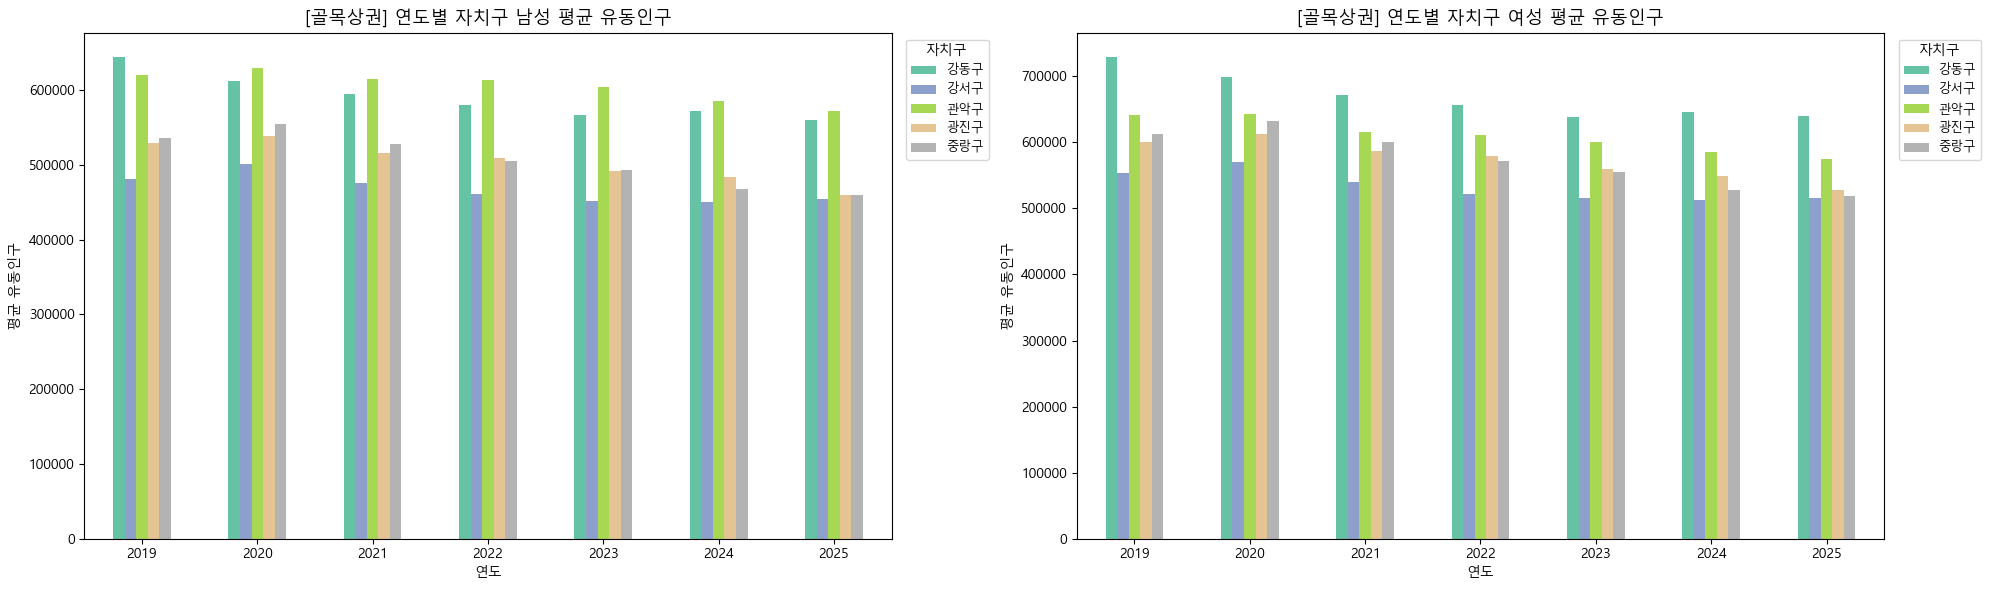


[골목상권] 연도별 남녀 평균 유동인구 TOP5 자치구
     남성_유동인구_수  여성_유동인구_수
자치구                      
관악구     605754     610262
강동구     589793     668304
중랑구     506237     573903
광진구     503741     573674
강서구     467560     532741



: 

In [ ]:
for 상권 in ['관광특구', '발달상권', '전통시장', '골목상권']:
    df_temp = 성별_분석[성별_분석['상권_구분_코드_명'] == 상권]
    
    # TOP 5 자치구
    top_구 = df_temp.groupby('자치구')['남성_유동인구_수'].mean().nlargest(5).index
    df_temp = df_temp[df_temp['자치구'].isin(top_구)]

    # 피벗
    남성_피벗 = df_temp.pivot_table(index='자치구', columns='연도', values='남성_유동인구_수', aggfunc='mean')
    여성_피벗 = df_temp.pivot_table(index='자치구', columns='연도', values='여성_유동인구_수', aggfunc='mean')

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    남성_피벗.T.plot(kind='bar', ax=axes[0], colormap='Set2')
    axes[0].set_title(f'[{상권}] 연도별 자치구 남성 평균 유동인구', fontsize=13)
    axes[0].set_xlabel('연도')
    axes[0].set_ylabel('평균 유동인구')
    axes[0].legend(title='자치구', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    axes[0].tick_params(axis='x', rotation=0)

    여성_피벗.T.plot(kind='bar', ax=axes[1], colormap='Set2')
    axes[1].set_title(f'[{상권}] 연도별 자치구 여성 평균 유동인구', fontsize=13)
    axes[1].set_xlabel('연도')
    axes[1].set_ylabel('평균 유동인구')
    axes[1].legend(title='자치구', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

    # 요약 출력
    print(f'\n[{상권}] 연도별 남녀 평균 유동인구 TOP5 자치구')
    print(df_temp.groupby('자치구')[['남성_유동인구_수', '여성_유동인구_수']].mean().round(0).astype(int).sort_values('남성_유동인구_수', ascending=False))
    print()